<a href="https://colab.research.google.com/github/mehrerm/TFM/blob/main/notebooks/EDA_ML_densidadRT_diag.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



En esta aplicación implementaremos un modelo de puntuación de riesgo poblacional a la mortalidad debido a los cánceres más comunes y su relación con las cantidades y tecnologías usadas en radioterapia por país.

In [71]:
#Cargo o importo pandas, numpy, Matplotlib,
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf # Importar ols desde aquí
import plotly.io as pio



import pwlf
import requests
import unicodedata
import os
from pathlib import Path

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, mean_squared_error

!pip install optbinning
from optbinning import OptimalBinning, Scorecard, BinningProcess
from sklearn.linear_model import LogisticRegression, LinearRegression
from urllib.parse import quote




#lugar donde se van guardando las figuras

output_path = Path("TFM/data/processed")
output_path.mkdir(parents=True, exist_ok=True)

fig_dir = "figuras"
os.makedirs(fig_dir, exist_ok=True)

#########################

#!plotly_get_chrome
#!sudo apt update && sudo apt-get install -y libnss3 libatk-bridge2.0-0 libcups2 libxcomposite1 libxdamage1 libxfixes3 libxrandr2 libgbm1 libxkbcommon0 libpango-1.0-0 libcairo2 libasound2
#!pip install --upgrade --force-reinstall kaleido plotly
#!pip install pwlf

Carga de datos ya depurados

In [72]:
url = "https://raw.githubusercontent.com/mehrerm/TFM/main/data/processed/"
#df_merged = pd.read_csv(url + "df_merged_WHO.csv")


df_merged = pd.read_csv(url + "df_merged_WHO_diag.csv")
display(df_merged.head())

,Year,Population,Population_male,Population_female,ISO3,Population id,Cancer label,Sex,Type,ASR (World),...,Total,Region Name,Year_Units,RT_m,GDP_per_capita,TAC,GammaC,MRI,Mammography,PET
0,2015,1292275.0,648341.0,643934.0,MUS,480,Lung,Male,Mortality,14.084766,...,109,Africa,2010,2.31,9630.543784,6.16,2.31,4.62,57.98,0.0
1,2015,1292275.0,648341.0,643934.0,MUS,480,Lung,Female,Mortality,5.710436,...,55,Africa,2010,2.31,9630.543784,6.16,2.31,4.62,57.98,0.0
2,2015,1292275.0,648341.0,643934.0,MUS,480,Breast,Female,Mortality,19.737396,...,177,Africa,2010,2.31,9630.543784,6.16,2.31,4.62,57.98,0.0
3,2015,1292275.0,648341.0,643934.0,MUS,480,Prostate,Male,Mortality,8.993800,...,65,Africa,2010,2.31,9630.543784,6.16,2.31,4.62,57.98,0.0
4,2015,1292275.0,648341.0,643934.0,MUS,480,Cervix,Female,Mortality,3.731733,...,33,Africa,2010,2.31,9630.543784,6.16,2.31,4.62,57.98,0.0


In [73]:
df_merged.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1085 entries, 0 to 1084
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               1085 non-null   int64  
 1   Population         1085 non-null   float64
 2   Population_male    1085 non-null   float64
 3   Population_female  1085 non-null   float64
 4   ISO3               1085 non-null   object 
 5   Population id      1085 non-null   int64  
 6   Cancer label       1085 non-null   object 
 7   Sex                1085 non-null   object 
 8   Type               1085 non-null   object 
 9   ASR (World)        1085 non-null   float64
 10  Crude rate         1085 non-null   float64
 11  Cumulative risk    1085 non-null   float64
 12  Total              1085 non-null   int64  
 13  Region Name        1085 non-null   object 
 14  Year_Units         1085 non-null   int64  
 15  RT_m               1085 non-null   float64
 16  GDP_per_capita     1085 

In [74]:
df_merged.isna().sum()[df_merged.isna().sum() > 0]

,0
TAC,445
GammaC,525
MRI,435
Mammography,715
PET,485


Como existen muchos datos missing, lo que se hará con estas variables es usarlas como descriptivas.

Antes de abordar los análisis de relación, se realizó un análisis exploratorio visual estratificado por año y sexo, con el objetivo de contextualizar la evolución temporal de la incidencia y la mortalidad por cáncer. Este análisis permitió identificar el periodo más adecuado para el estudio principal, teniendo en cuenta posibles distorsiones en los indicadores de salud asociadas a acontecimientos excepcionales, como la pandemia de COVID-19 en el 2020, que alteró significativamente los patrones de diagnóstico y tratamiento. Con esto además, podemos visualizar como evoluciona la incidencia y mortalidad en el tiempo, si existen diferencias sistemáticas por sexo y detectar patrones globales.





In [75]:
df_merged = df_merged.drop(columns=['Crude rate', 'Cumulative risk', "Year_Units", 'Total', "Mammography"])

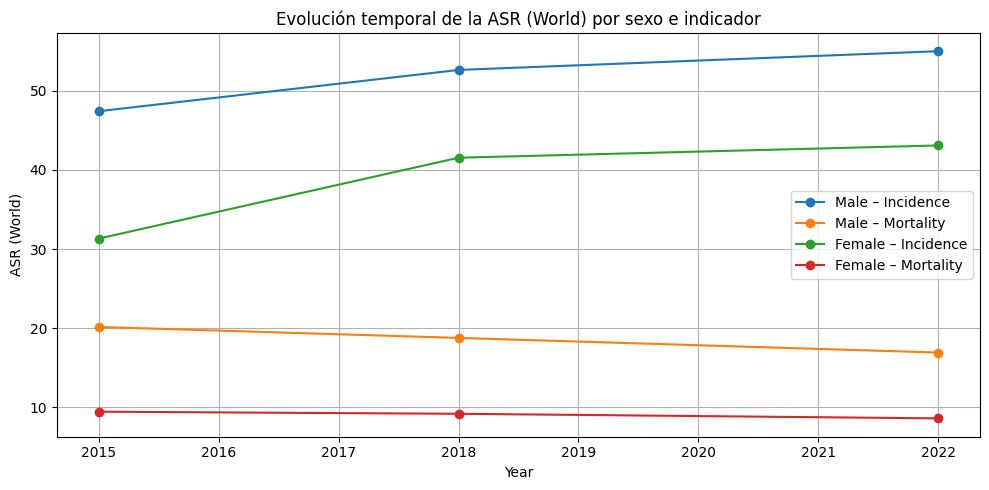

In [76]:
df_trend = (
    df_merged
    .dropna(subset=["Year", "ASR (World)", "Sex", "Type"])
    .groupby(["Year", "Sex", "Type"], as_index=False)
    .agg({"ASR (World)": "mean"})
    .sort_values("Year")
)

%matplotlib inline

plt.figure(figsize=(10,5))

for sex in ["Male", "Female"]:
    for t in ["Incidence", "Mortality"]:
        sub = df_trend[(df_trend["Sex"] == sex) & (df_trend["Type"] == t)]
        plt.plot(
            sub["Year"],
            sub["ASR (World)"],
            marker="o",
            label=f"{sex} – {t}"
        )

plt.xlabel("Year")
plt.ylabel("ASR (World)")
plt.title("Evolución temporal de la ASR (World) por sexo e indicador")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{fig_dir}/fig01_figure_ASR_anno.jpg", dpi=300, bbox_inches="tight")
plt.show()


#Se grafica entonces la evolución temporal de la ASR, estratificado por sexo

En la serie temporal no parece evidenciar o estar afecto por el COVID19, los datos del 2018 y 2022 son bastante parecidos, esto también nos podría suponer que no ha evolucionado significativamente la tasa de mortalidad, lo que si queda claro, es que los hombres y mujeres tienen incidencias y mortalidad distintas, con casi los mismo comportamientos pero de magnitud diferente.
En nuestro estudio existen solamente tres años porque son los años que se tiene registro de la cantidad de equipos de radioterapia y su evolución a lo largo de esos tres años registrados, como ya se mencionó en la depuración, se consideró sumarle 5 años a los registros  de los equipos ya que es ese tiempo aproximadamente en el que se puede saber si efectivamente los equipos de radioterapia (A partir de ahora, RT) han surtido efecto en la mortalidad.





Se busca entonces ver como se comporta la mortalidad e incidencia por año.

In [77]:
idx = (
    df_merged
    .groupby(["ISO3", "Sex", "Type"])["Year"]
    .idxmax()
)

df_latest = df_merged.loc[idx].reset_index(drop=True)


<Figure size 1000x500 with 0 Axes>

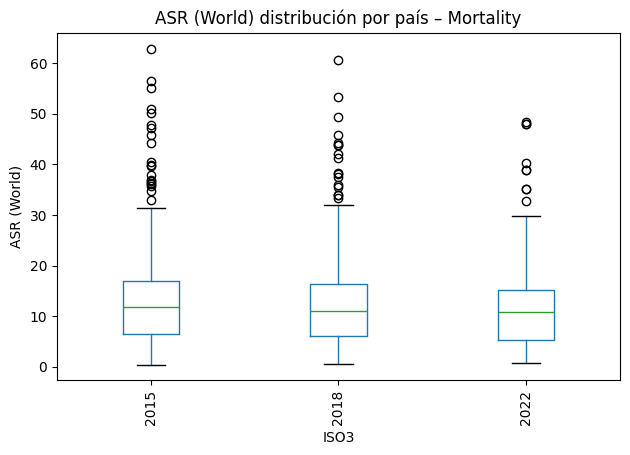

<Figure size 1000x500 with 0 Axes>

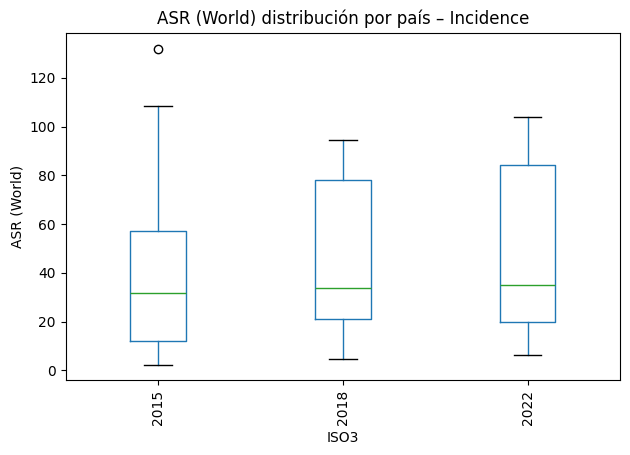

                count       mean        std       min        25%        50%  \
Type      Year                                                                
Incidence 2015  210.0  37.760526  29.306871  2.279390  11.796643  31.704972   
          2018   20.0  45.966859  32.841461  4.611827  21.016206  33.647772   
          2022   30.0  47.842069  34.262574  6.242416  19.646427  34.806863   
Mortality 2015  300.0  13.748971  10.739895  0.388140   6.419846  11.762913   
          2018  280.0  13.035889  10.141584  0.541023   6.052555  11.010309   
          2022  245.0  11.950008   8.931221  0.668701   5.359303  10.791069   

                      75%         max  
Type      Year                         
Incidence 2015  57.320187  132.046692  
          2018  77.994580   94.690075  
          2022  84.118158  103.896318  
Mortality 2015  17.032979   62.917421  
          2018  16.400917   60.588763  
          2022  15.227584   48.374439  


In [78]:
df_plot = df_merged.copy()


for t in df_plot["Type"].unique():
    plt.figure(figsize=(10,5))

    df_plot[df_plot["Type"] == t].boxplot(
        column="ASR (World)",
        by="Year",
        grid=False,
        rot=90
    )

    plt.title(f"ASR (World) distribución por país – {t}")
    plt.suptitle("")
    plt.xlabel("ISO3")
    plt.ylabel("ASR (World)")
    plt.tight_layout()
    plt.savefig(f"{fig_dir}/fig02_boxplot_ASR_{t}.jpg", dpi=300, bbox_inches="tight")
    plt.show()

stats_simple = (
    df_plot
    .groupby(["Type", "Year"])["ASR (World)"]
    .describe()
)

print(stats_simple)



Estas figuras muestran que la mortalidad presenta una elevada heterogeneidad entre países, outliers por encima de la media. Por el contrario, la incidencia muestra una distribución más homogenea.


Para continuar con el análisis estadístico y valorar que año y paises utilizar en nuestro trabajo, se busca entonces valorar que paises tienen los datos de incidencia y/o mortalidad.


Es importante resaltar desde el principio de que nuestra variable objetivo es la tasa de mortalidad  ASR (World) y ver que relación tiene con los equipos de radioaterapia, incidencia, PIB per capita, sexo, región, etc.



In [79]:
#cuantos paises hay con año, tipo de cancer y tipo

counts = (
    df_merged
    .groupby(
        ["ISO3", "Year", "Cancer label", "Type"]
    )
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

 # cuantos países tienen los datos completos (both) o incompletos?

counts["both"] = (
    (counts.get("Incidence", 0) > 0) &
    (counts.get("Mortality", 0) > 0)
)

counts["only_incidence"] = (
    (counts.get("Incidence", 0) > 0) &
    (counts.get("Mortality", 0) == 0)
)

counts["only_mortality"] = (
    (counts.get("Incidence", 0) == 0) &
    (counts.get("Mortality", 0) > 0)
)

summary = {
    "Total combinaciones país–año–cáncer": len(counts),
    "Con incidencia y mortalidad": counts["both"].sum(),
    "Solo incidencia": counts["only_incidence"].sum(),
    "Solo mortalidad": counts["only_mortality"].sum(),
}
print(
    f"Total combinaciones país–año–cáncer: {summary['Total combinaciones país–año–cáncer']}\n"
    f"Con incidencia y mortalidad: {summary['Con incidencia y mortalidad']}\n"
    f"Solo incidencia: {summary['Solo incidencia']}\n"
    f"Solo mortalidad: {summary['Solo mortalidad']}"
)


#Un resumen por año

by_year = (
    counts
    .groupby("Year")[["both", "only_incidence", "only_mortality"]]
    .sum()
)

print(by_year)

#resumen por pais

by_country = (
    counts
    .groupby("ISO3")[["both", "only_incidence", "only_mortality"]]
    .sum()
    .sort_values("both")
)





Total combinaciones país–año–cáncer: 648
Con incidencia y mortalidad: 152
Solo incidencia: 48
Solo mortalidad: 448
Type  both  only_incidence  only_mortality
Year                                      
2015   136              32             104
2018     8               8             216
2022     8               8             128


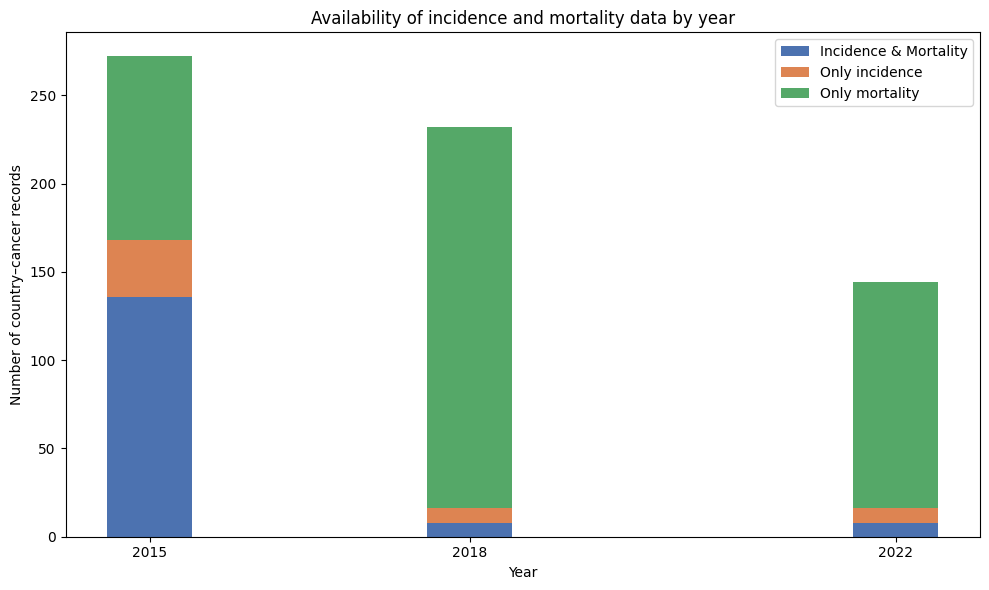

In [80]:
plt.figure(figsize=(10, 6))

plt.bar(
    by_year.index,
    by_year["both"],
    label="Incidence & Mortality",
    color="#4C72B0"
)

plt.bar(
    by_year.index,
    by_year["only_incidence"],
    bottom=by_year["both"],
    label="Only incidence",
    color="#DD8452"
)

plt.bar(
    by_year.index,
    by_year["only_mortality"],
    bottom=by_year["both"] + by_year["only_incidence"],
    label="Only mortality",
    color="#55A868"
)

plt.xlabel("Year")
plt.ylabel("Number of country–cancer records")
plt.title("Availability of incidence and mortality data by year")
plt.legend()
plt.tight_layout()
plt.savefig(f"{fig_dir}/Incidence_mortality_data_year.jpg", dpi=300, bbox_inches="tight")
plt.xticks(by_year.index.astype(int))


plt.show()


Se observó una reducción generalizada en el número de países con datos de incidencia disponibles a partir de 2018 para todos los tipos de cáncer analizados. Este cambio de cobertura limita la comparabilidad temporal de las medias anuales posteriores a dicho año, por lo que los análisis longitudinales se interpretan con cautela y se prioriza el uso de mortalidad como variable objetivo, es importante resaltar que debido a los pocos datos registrados, no se estratificará por año, se entiende que habrá una colinealidad bastante fuerte, pero la idea del estudio es ver como valorar la necesidad de equipos de radioterapia en el caso de tener registros solidos y amplios sobre las disponibilidad de los mismos.

In [ ]:

df_merged_all = df_merged.copy()


# Quedarse solo con mortalidad
df_merged_all = df_merged_all[df_merged_all["Type"] == "Mortality"].copy()



# Ver qué años hay y cuántas observaciones por año
df_merged_all["Year"].value_counts().sort_index()


Con estos datos, ahora si, se procede a evaluar con gráficos y estadísitcas que se tiene por cada tipo de cancer.

In [82]:
df_merged_all["Cancer label"].unique()

array(['Lung', 'Breast', 'Prostate', 'Cervix'], dtype=object)

Con la finalidad de entender si existe algún patrón de comportamiento de estos tipos de cancer con variables como PIB y RT, se procede a utilizar graficos de dispersión.

In [83]:
#Se renombran las columnas
df_model = df_merged_all.rename(columns={
    "Cancer label": "Cancer",
    "Region Name": "Region",
   #"Country_harmonized": "Country",
    "ASR (World)" : "ASR",
    "GDP_per_capita" : "GDP",
    "RT_m" : "RT"
})




In [84]:
df_model.head()

,Year,Population,Population_male,Population_female,ISO3,Population id,Cancer,Sex,Type,ASR,Region,RT,GDP,TAC,GammaC,MRI,PET
0,2015,1292275.0,648341.0,643934.0,MUS,480,Lung,Male,Mortality,14.084766,Africa,2.31,9630.543784,6.16,2.31,4.62,0.0
1,2015,1292275.0,648341.0,643934.0,MUS,480,Lung,Female,Mortality,5.710436,Africa,2.31,9630.543784,6.16,2.31,4.62,0.0
2,2015,1292275.0,648341.0,643934.0,MUS,480,Breast,Female,Mortality,19.737396,Africa,2.31,9630.543784,6.16,2.31,4.62,0.0
3,2015,1292275.0,648341.0,643934.0,MUS,480,Prostate,Male,Mortality,8.993800,Africa,2.31,9630.543784,6.16,2.31,4.62,0.0
4,2015,1292275.0,648341.0,643934.0,MUS,480,Cervix,Female,Mortality,3.731733,Africa,2.31,9630.543784,6.16,2.31,4.62,0.0


Se cambia a escala logaritmica el PIB.

In [85]:
df_model['log_GDP'] = np.log(df_model['GDP'])

In [86]:
!plotly_get_chrome


Plotly will install a copy of Google Chrome to be used for generating static images of plots.
Chrome will be installed at: None
Do you want to proceed? [y/n] y
Installing Chrome for Plotly...
Chrome installed successfully.
The Chrome executable is now located at: /usr/local/lib/python3.12/dist-packages/choreographer/cli/browser_exe/chrome-linux64/chrome


In [87]:

pio.templates.default = "plotly_white"
pio.kaleido.scope.default_format = "png"
pio.kaleido.scope.default_width = 1200
pio.kaleido.scope.default_height = 800
pio.kaleido.scope.default_scale = 2

def plot_all_cancers(df, x, y):
    fig = px.scatter(
        df,
        x=x,
        y=y,
        color="Cancer",
        facet_col="Sex",
        facet_row="Year",
        hover_name="ISO3",
        title=f"Grafica de dispersion entre {x} y {y} por tipo de cáncer, año y sexo"
    )
    fig.update_layout(height=800, width=1000)
    fig.write_image(f"{fig_dir}/scatter_{x}_vs_{y}_by_sex.png", scale=3)
    fig.show()


plot_all_cancers(df_model, "log_GDP", "ASR")

plot_all_cancers(df_model, "RT", "ASR")


/tmp/ipython-input-1661359527.py:2: DeprecationWarning:


Use of plotly.io.kaleido.scope.default_format is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_format instead.


/tmp/ipython-input-1661359527.py:3: DeprecationWarning:


Use of plotly.io.kaleido.scope.default_width is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_width instead.


/tmp/ipython-input-1661359527.py:4: DeprecationWarning:


Use of plotly.io.kaleido.scope.default_height is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_height instead.


/tmp/ipython-input-1661359527.py:5: DeprecationWarning:


Use of plotly.io.kaleido.scope.default_scale is deprecated and support will be removed after September 2025.
Please use plotly.io.defaults.default_scale instead.




Se observa una tendencia general a que, crece el PIB per cápita (log_GDP) con el ASR y en cierto punto es que empieza a bajar ASR, esto posiblemente se debe al tabaquismo, contaminación u otro factor no lineal. Esto sugiere que el desarrollo económico hasta cierto punto puede ayudar, asi conjuntamente el sistema sanitario, ambos juegan un papel crucial en la reducción de la mortalidad por cáncer. Sin embargo, esta relación es confusa y varía entre cánceres. Por ejemplo, algunos cánceres pueden mostrar una disminución más pronunciada que otros a medida que aumenta el PIB.

ASR vs. Radioterapia (RT): La relación entre la disponibilidad de equipos de radioterapia y la mortalidad es más compleja y específica de cada cáncer.

Cáncer de Cérvix: Visualmente, es probable que se observe que un aumento en la disponibilidad de RT se correlaciona con una disminución en la ASR, especialmente en rangos bajos de RT, lo que podría ser debido a un efecto umbral. Los puntos de datos para este cáncer se concentran en la parte inferior izquierda de los gráficos cuando hay poca RT y se desplazan aún mas hacia abajo y a la derecha a medida que aumenta la RT.
Cáncer de Mama y Próstata: Para estos cánceres, la relación con la RT parece menos consistente o más dispersa. Los puntos de datos pueden estar más agrupados o mostrar una correlación más débil.

Diferencias por Sexo y Año: Los gráficos revelan que las tendencias pueden variar entre hombres y mujeres para el mismo tipo de cáncer, y también a lo largo de los años, usando el cancer de pulmon para este fin.


Con el objetivo de identificar las variables que podrían influir en la tasa de mortalidad, se realiza un análisis mediante una matriz de correlaciones, diferenciando por sexo, dado que los patrones de incidencia y mortalidad presentan comportamientos significativamente distintos entre hombres y mujeres.


In [88]:
df_model_f = df_model[df_model["Sex"] == "Female"].copy()
df_model_f.drop(columns=["Population_male", "Type", "Sex"], inplace=True)


In [89]:
df_model_f.info()

<class 'pandas.core.frame.DataFrame'>
Index: 495 entries, 1 to 1084
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               495 non-null    int64  
 1   Population         495 non-null    float64
 2   Population_female  495 non-null    float64
 3   ISO3               495 non-null    object 
 4   Population id      495 non-null    int64  
 5   Cancer             495 non-null    object 
 6   ASR                495 non-null    float64
 7   Region             495 non-null    object 
 8   RT                 495 non-null    float64
 9   GDP                495 non-null    float64
 10  TAC                288 non-null    float64
 11  GammaC             252 non-null    float64
 12  MRI                294 non-null    float64
 13  PET                261 non-null    float64
 14  log_GDP            495 non-null    float64
dtypes: float64(10), int64(2), object(3)
memory usage: 61.9+ KB


In [90]:
df_model_m = df_model[df_model["Sex"] == "Male"].copy()
df_model_m.drop(columns=["Population_female", "Type", "Sex"], inplace=True)
df_model_m.head()


,Year,Population,Population_male,ISO3,Population id,Cancer,ASR,Region,RT,GDP,TAC,GammaC,MRI,PET,log_GDP
0,2015,1292275.0,648341.0,MUS,480,Lung,14.084766,Africa,2.31,9630.543784,6.16,2.31,4.62,0.0,9.172695
3,2015,1292275.0,648341.0,MUS,480,Prostate,8.993800,Africa,2.31,9630.543784,6.16,2.31,4.62,0.0,9.172695
5,2018,1288833.0,646826.0,MUS,480,Lung,10.543072,Africa,2.41,11818.748062,6.43,2.41,4.82,0.0,9.377442
8,2018,1288833.0,646826.0,MUS,480,Prostate,12.165378,Africa,2.41,11818.748062,6.43,2.41,4.82,0.0,9.377442
10,2022,1276130.0,638999.0,MUS,480,Lung,10.937588,Africa,3.14,10246.501746,NaN,NaN,NaN,NaN,9.234692


In [91]:
df_model_m.info()

<class 'pandas.core.frame.DataFrame'>
Index: 330 entries, 0 to 1083
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             330 non-null    int64  
 1   Population       330 non-null    float64
 2   Population_male  330 non-null    float64
 3   ISO3             330 non-null    object 
 4   Population id    330 non-null    int64  
 5   Cancer           330 non-null    object 
 6   ASR              330 non-null    float64
 7   Region           330 non-null    object 
 8   RT               330 non-null    float64
 9   GDP              330 non-null    float64
 10  TAC              192 non-null    float64
 11  GammaC           168 non-null    float64
 12  MRI              196 non-null    float64
 13  PET              174 non-null    float64
 14  log_GDP          330 non-null    float64
dtypes: float64(10), int64(2), object(3)
memory usage: 41.2+ KB


Ahora, se buscan las variables que nos interesa

In [92]:
df = df_model_m.copy()


cols_corr_m = [
    "ASR", "RT", "log_GDP"
]

In [93]:


corr_m = df[cols_corr_m].corr()
corr_m

,ASR,RT,log_GDP
ASR,1.000000,0.017513,-0.018381
RT,0.017513,1.000000,0.755825
log_GDP,-0.018381,0.755825,1.000000


In [94]:



cols_corr_f = [
    "ASR", "RT", "log_GDP"
]
df[cols_corr_f].corr()

,ASR,RT,log_GDP
ASR,1.000000,0.017513,-0.018381
RT,0.017513,1.000000,0.755825
log_GDP,-0.018381,0.755825,1.000000


Lo que se puede ver es que la señal es bastante débil y contradictoria tanto para hombres como mujeres si juntamos todos los tipos de cancer, ahora bien, si los esparamos

In [95]:
def plot_corr_heatmap(df, cols_corr, cancer):
  df_ = df[df["Cancer"] == cancer]
  # Determine sex from the dataframe passed
  current_sex = "Male" if "Population_male" in df.columns else "Female"

  corr_ = df_[cols_corr].corr()

  plt.figure(figsize=(8, 6))
  sns.heatmap(
    corr_,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0
  )
  plt.title("Correlation heatmap – " f"{cancer}")
  plt.tight_layout()
  # Save the figure BEFORE showing it
  plt.savefig(f"{fig_dir}/heatmap_corr_{cancer}_{current_sex}.jpg", dpi=300, bbox_inches="tight")
  plt.show()

  return corr_, df_

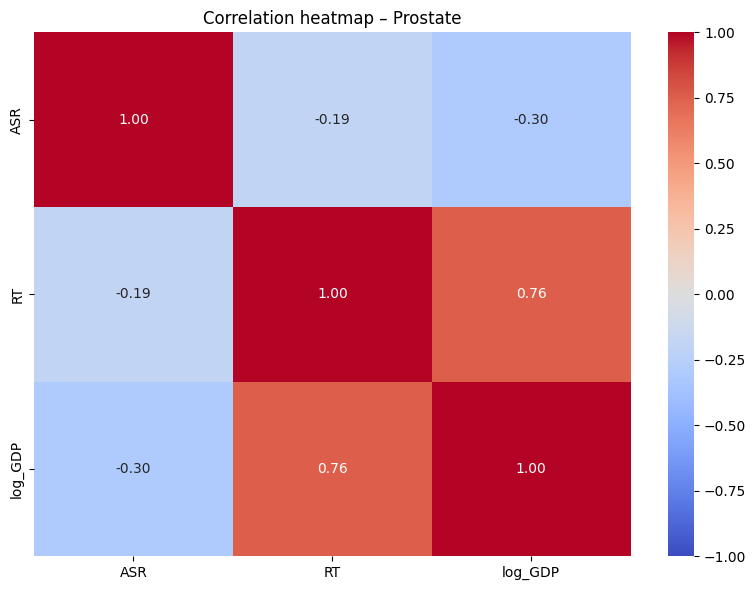

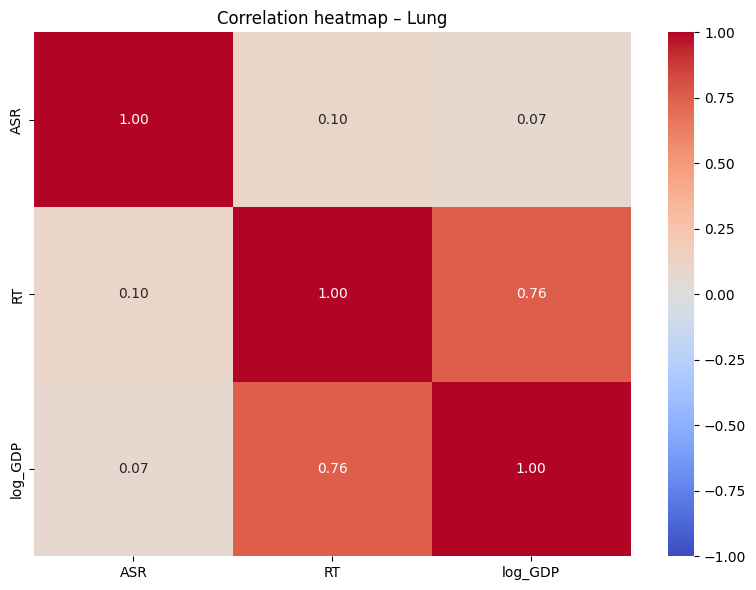

In [96]:
corr_prostate, df_prostate = plot_corr_heatmap(df_model_m, cols_corr_m, "Prostate")

corr_lung_m, df_lung_m = plot_corr_heatmap(df_model_m, cols_corr_m, "Lung")


En estos mapas de calor podemos ver una muy fuerte correlación entre el pib per capita y los equipos RT, pero

In [97]:
df = df_model_f.copy()


cols_corr_f = [
    "ASR", "RT", "Population_female", "log_GDP"
]

corr = df[cols_corr_f].corr()
corr

,ASR,RT,Population_female,log_GDP
ASR,1.000000,0.072251,-0.010725,0.031906
RT,0.072251,1.000000,0.275557,0.755825
Population_female,-0.010725,0.275557,1.000000,0.117930
log_GDP,0.031906,0.755825,0.117930,1.000000


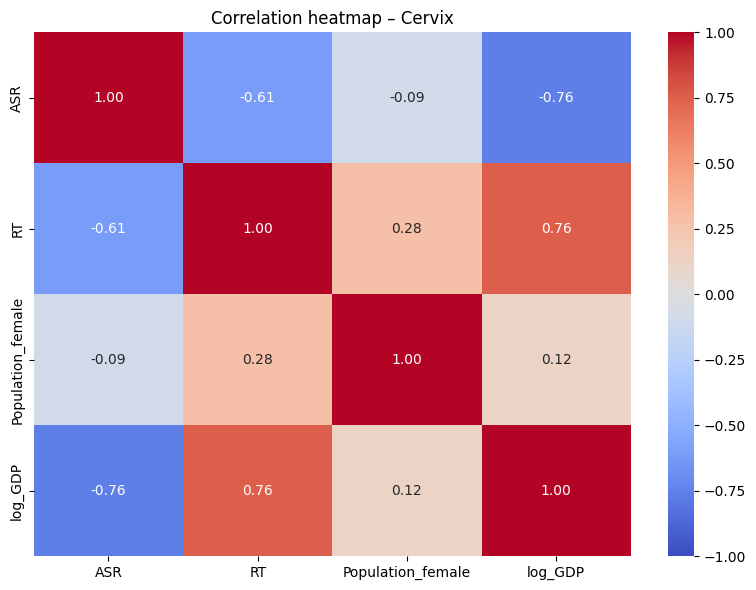

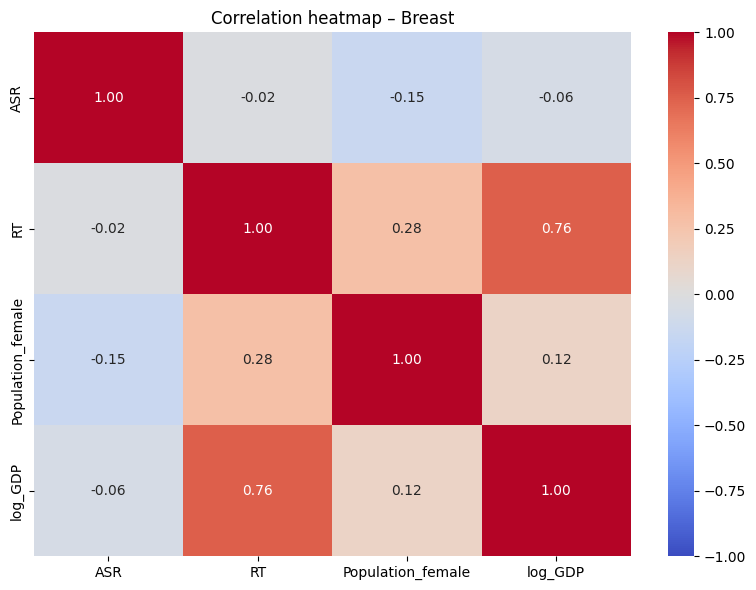

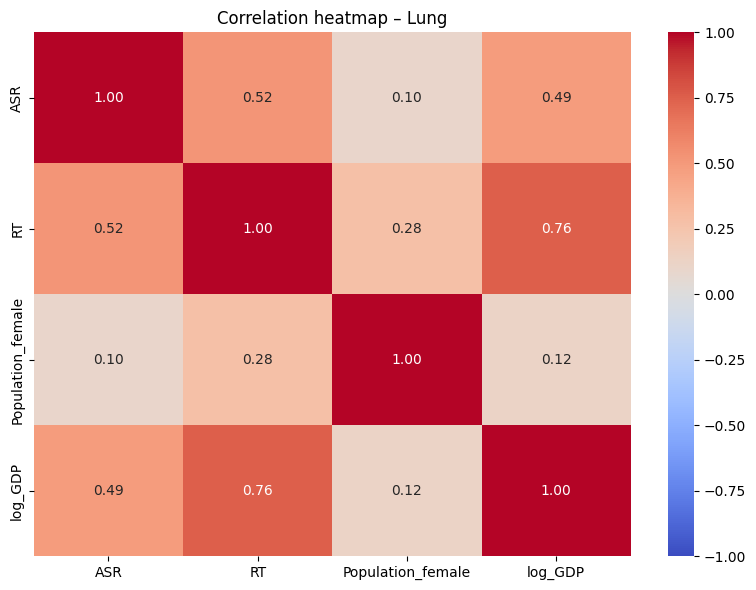

In [98]:
corr_cervix, df_cervix = plot_corr_heatmap(df_model_f, cols_corr_f, "Cervix")

corr_breast, df_breast = plot_corr_heatmap(df_model_f, cols_corr_f, "Breast")

corr_lung_f, df_lung_f = plot_corr_heatmap(df_model_f, cols_corr_f, "Lung")

Analizando los mapas de calor, encontramos que paradojicamente existen tipos de cáncer que aumentan con la cantidad de equipos y PIB per capita, este es el caso de pulmón en ambos sexos, sin embargo, se puede ver claramente que tanto para cervix como prostata, tratamientos muy bien protocolizados en tratamientos con radioterapia externa, si tienen un gran impacto, el valor negativo nos indica que disminuye a media que aumenta el número de la variable predictora.



A partir de aquí y debido a que tenemos dos variables predictoras, utilizaremos métodos adecuados a lo que tenemos disponible.

¿Existe un umbral de numero de RT donde se puede optimizar sus bondades y aún así optener buenos resultados epidemiológicos tanto en próstata con en cervix?
O ¿Entre más equipos existe menos mortalidad?

Empezando con un modelo base sencillo: regresión lineal.

### Regresión lineal para hombres (ASR ~ log_GDP + RT)

In [99]:
model_prostate_ols = smf.ols(
    "ASR ~ log_GDP + RT",
    data=df_prostate
).fit()

print(model_prostate_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                    ASR   R-squared:                       0.091
Model:                            OLS   Adj. R-squared:                  0.080
Method:                 Least Squares   F-statistic:                     8.125
Date:                Sun, 15 Feb 2026   Prob (F-statistic):           0.000434
Time:                        10:03:41   Log-Likelihood:                -484.55
No. Observations:                 165   AIC:                             975.1
Df Residuals:                     162   BIC:                             984.4
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     28.2940      4.968      5.696      0.0

Con un modelo OLS sencillo, explica en su conjunto solamente el 9% de la variabilidad se debe a estas variables y paradojicamente, RT en positivo, sin embargo, el PIB es estaditicamente significativa, mientras que RT no lo es, por lo tanto, no hay suficiente evidencia de que RT tenga un efecto lineal.

### Evaluación de RMSE y Validación Cruzada para Cáncer de Próstata

In [100]:
# --- RMSE para el modelo OLS de Próstata ya ajustado ---
X_prostate = df_prostate[["log_GDP", "RT"]]
y_pred_prostate = model_prostate_ols.predict(X_prostate)
rmse_prostate = np.sqrt(mean_squared_error(df_prostate["ASR"], y_pred_prostate))
print(f"RMSE (Modelo OLS Próstata): {rmse_prostate:.3f}")

# --- Validación Cruzada para Próstata ---

y_prostate = df_prostate["ASR"]

lr_prostate = LinearRegression()
cv_prostate = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores_prostate = cross_val_score(
    lr_prostate, X_prostate, y_prostate,
    cv=cv_prostate,
    scoring="r2"
)

rmse_scores_prostate = -cross_val_score(
    lr_prostate, X_prostate, y_prostate,
    cv=cv_prostate,
    scoring="neg_root_mean_squared_error"
)

print(f"CV R² (Próstata): {r2_scores_prostate.mean():.3f} ± {r2_scores_prostate.std():.3f}")
print(f"CV RMSE (Próstata): {rmse_scores_prostate.mean():.3f} ± {rmse_scores_prostate.std():.3f}")

RMSE (Modelo OLS Próstata): 4.562
CV R² (Próstata): 0.010 ± 0.119
CV RMSE (Próstata): 4.627 ± 0.707


En las métricas se puede observar que tanto el PIB como RT explican muy poca de la variabilidad de la mortalidad documentada, tan solo un 8%. Otro punto a considerar es que el coeficiente, además de ser casi nulo para RT, es positivo, algo que no tiene mucho sentido, viendo los diagramas de dispersión se puede ver que son puntos dispersos. Sin embargo, semuestra que el PIB si es significativo con ese 8% de variabilidad, quedando como descartado en el estudio, continuar buscando modelos para este tipo de cancer.

### Regresión lineal para mujeres (ASR ~ log_GDP + RT)

In [101]:
model_cervix_ols = smf.ols(
    "ASR ~ log_GDP + RT", # Añadida la coma aquí
    data=df_cervix
).fit()

print(model_cervix_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                    ASR   R-squared:                       0.578
Model:                            OLS   Adj. R-squared:                  0.572
Method:                 Least Squares   F-statistic:                     110.8
Date:                Sun, 15 Feb 2026   Prob (F-statistic):           4.81e-31
Time:                        10:03:41   Log-Likelihood:                -326.95
No. Observations:                 165   AIC:                             659.9
Df Residuals:                     162   BIC:                             669.2
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     22.7322      1.911     11.893      0.0

In [102]:
model_cervix_ols = smf.ols(
    "ASR ~ log_GDP", # Añadida la coma aquí
    data=df_cervix
).fit()

print(model_cervix_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                    ASR   R-squared:                       0.574
Model:                            OLS   Adj. R-squared:                  0.572
Method:                 Least Squares   F-statistic:                     220.1
Date:                Sun, 15 Feb 2026   Prob (F-statistic):           4.68e-32
Time:                        10:03:41   Log-Likelihood:                -327.56
No. Observations:                 165   AIC:                             659.1
Df Residuals:                     163   BIC:                             665.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     24.1711      1.389     17.402      0.0

Con resultados donde se predice el 58% de la variabilidad, se puede decir que el PIB per capita es el dominante y el intervalo está lejos de cero. Esto es coherente con que la infraestructura sanitaria está correlacionada con desarrollo economico, sin embargo, RT tiene poca significancia, demostrando aqui que posiblemente tiene un comportamiento no lineal.

### Evaluación de RMSE y Validación Cruzada para Cáncer de Cérvix

In [103]:
# --- RMSE para el modelo OLS de Cérvix ya ajustado ---
y_pred_cervix = model_cervix_ols.predict(df_cervix)
rmse_cervix = np.sqrt(mean_squared_error(df_cervix["ASR"], y_pred_cervix))
print(f"RMSE (Modelo OLS Cérvix): {rmse_cervix:.3f}")

# --- Validación Cruzada para Cérvix ---
X_cervix = df_cervix[["log_GDP", "RT"]]
y_cervix = df_cervix["ASR"]

lr_cervix = LinearRegression()
cv_cervix = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores_cervix = cross_val_score(
    lr_cervix, X_cervix, y_cervix,
    cv=cv_cervix,
    scoring="r2"
)

rmse_scores_cervix = -cross_val_score(
    lr_cervix, X_cervix, y_cervix,
    cv=cv_cervix,
    scoring="neg_root_mean_squared_error"
)

print(f"CV R² (Cérvix): {r2_scores_cervix.mean():.3f} ± {r2_scores_cervix.std():.3f}")
print(f"CV RMSE (Cérvix): {rmse_scores_cervix.mean():.3f} ± {rmse_scores_cervix.std():.3f}")

RMSE (Modelo OLS Cérvix): 1.762
CV R² (Cérvix): 0.556 ± 0.081
CV RMSE (Cérvix): 1.756 ± 0.228


VERIFICACIÓN DE DATOS

📊 Primeras filas de df_cervix:
   ISO3        ASR    log_GDP    RT
4   MUS   3.731733   9.172695  2.31
9   MUS   4.173902   9.377442  2.41
14  MUS   3.799936   9.234692  3.14
24  ZAF  12.971971   8.718054  0.60
29  ZAF  13.175513   8.841329  0.57
34  KGZ   8.765788   7.157362  0.54
39  UZB   5.426419   7.938513  0.66
44  UZB   6.120381   7.502785  0.62
59  JPN   2.116161  10.461978  7.19
64  JPN   2.061202  10.590394  7.17

📊 Estadísticas descriptivas:
              ASR     log_GDP          RT
count  165.000000  165.000000  165.000000
mean     3.667999    9.870272    4.536242
std      2.708875    0.988413    3.416306
min      0.388140    7.157362    0.000000
25%      1.446800    9.212819    1.470000
50%      3.074132    9.914482    3.960000
75%      5.101708   10.643751    6.780000
max     13.175513   11.669303   13.160000

📊 Valores nulos:
ASR        0
log_GDP    0
RT         0
dtype: int64

📊 Correlaciones:
              ASR   log_GDP        RT
ASR      1.00000

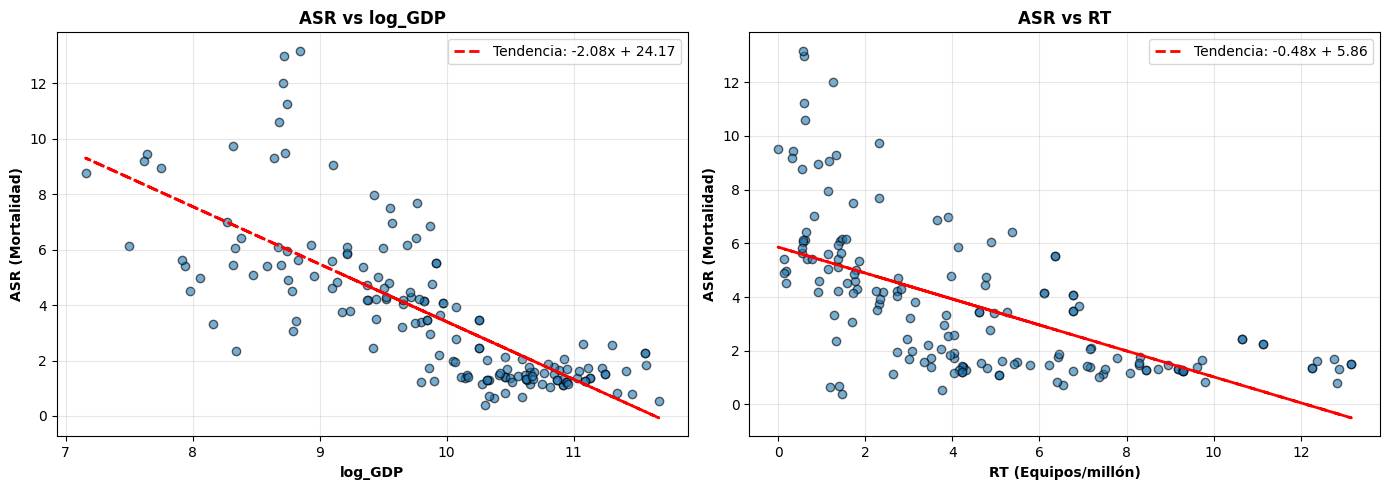

In [104]:
# ============================================
# 1. VERIFICAR DATOS
# ============================================
print("="*80)
print("VERIFICACIÓN DE DATOS")
print("="*80)

# Revisar estructura
print("\n📊 Primeras filas de df_cervix:")
print(df_cervix[['ISO3', 'ASR', 'log_GDP', 'RT']].head(10))

print("\n📊 Estadísticas descriptivas:")
print(df_cervix[['ASR', 'log_GDP', 'RT']].describe())

print("\n📊 Valores nulos:")
print(df_cervix[['ASR', 'log_GDP', 'RT']].isnull().sum())

print("\n📊 Correlaciones:")
print(df_cervix[['ASR', 'log_GDP', 'RT']].corr())

# ============================================
# 2. GRÁFICO DE DISPERSIÓN
# ============================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ASR vs log_GDP
axes[0].scatter(df_cervix['log_GDP'], df_cervix['ASR'], alpha=0.6, edgecolors='k')
axes[0].set_xlabel('log_GDP', fontweight='bold')
axes[0].set_ylabel('ASR (Mortalidad)', fontweight='bold')
axes[0].set_title('ASR vs log_GDP', fontweight='bold')
axes[0].grid(alpha=0.3)

# Línea de tendencia
z = np.polyfit(df_cervix['log_GDP'], df_cervix['ASR'], 1)
p = np.poly1d(z)
axes[0].plot(df_cervix['log_GDP'], p(df_cervix['log_GDP']),
             "r--", linewidth=2, label=f'Tendencia: {z[0]:.2f}x + {z[1]:.2f}')
axes[0].legend()

# ASR vs RT
axes[1].scatter(df_cervix['RT'], df_cervix['ASR'], alpha=0.6, edgecolors='k')
axes[1].set_xlabel('RT (Equipos/millón)', fontweight='bold')
axes[1].set_ylabel('ASR (Mortalidad)', fontweight='bold')
axes[1].set_title('ASR vs RT', fontweight='bold')
axes[1].grid(alpha=0.3)

# Línea de tendencia
z2 = np.polyfit(df_cervix['RT'], df_cervix['ASR'], 1)
p2 = np.poly1d(z2)
axes[1].plot(df_cervix['RT'], p2(df_cervix['RT']),
             "r--", linewidth=2, label=f'Tendencia: {z2[0]:.2f}x + {z2[1]:.2f}')
axes[1].legend()

plt.tight_layout()
plt.show()


El error medio de ambos modelos OLS y validación cruzada nos indica que el modelo se equivoca en promedio +/- 1.8 muertes/100K, el modelo explica más de 50% de la variabilidad asi como para validación cruzada, y es bastante parecido al modelo OLS, siendo entonces en este caso, un buen modelo para explicar el comportamiento del cancer de cervix, donde el PIB per capita es quien tiene significancia.

Para mama

In [105]:
model_breast_ols = smf.ols(
    "ASR ~ log_GDP + RT",
    data=df_breast
).fit()

print(model_breast_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                    ASR   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                 -0.008
Method:                 Least Squares   F-statistic:                    0.3468
Date:                Sun, 15 Feb 2026   Prob (F-statistic):              0.707
Time:                        10:03:42   Log-Likelihood:                -434.27
No. Observations:                 165   AIC:                             874.5
Df Residuals:                     162   BIC:                             883.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     16.2410      3.663      4.434      0.0

In [106]:
model_breast_ols = smf.ols(
    "ASR ~ log_GDP",
    data=df_breast
).fit()

print(model_breast_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                    ASR   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.003
Method:                 Least Squares   F-statistic:                    0.5302
Date:                Sun, 15 Feb 2026   Prob (F-statistic):              0.468
Time:                        10:03:42   Log-Likelihood:                -434.35
No. Observations:                 165   AIC:                             872.7
Df Residuals:                     163   BIC:                             878.9
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     15.2148      2.653      5.734      0.0

Con respecto al cancer de mama, las variables carecen de significancia y explican tan solo el 0.3% de la variabilidad, asumiendo que en este caso, existen factores externos como la detección precoz, cirguría y quimioterapia predominan la influencia de la mortalidad en cancer de mama, independientemente del estatus económico del país, esto podría demostrar que las políticas y ayudas con acuerdos de colaboración dan sus frutos en este tipo de cáncer. Quedando entonces por descartado para continuar con el estudio.

##Para pulmon en mujeres

In [107]:
model_lung_f_ols = smf.ols(
    "ASR ~ log_GDP + RT",
    data=df_lung_f
).fit()

print(model_lung_f_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                    ASR   R-squared:                       0.292
Model:                            OLS   Adj. R-squared:                  0.284
Method:                 Least Squares   F-statistic:                     33.48
Date:                Sun, 15 Feb 2026   Prob (F-statistic):           6.77e-13
Time:                        10:03:42   Log-Likelihood:                -492.99
No. Observations:                 165   AIC:                             992.0
Df Residuals:                     162   BIC:                             1001.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -4.9872      5.229     -0.954      0.3

In [108]:
model_lung_f_ols = smf.ols(
    "ASR ~ log_GDP + RT",
    data=df_lung_f
).fit()

print(model_lung_f_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                    ASR   R-squared:                       0.292
Model:                            OLS   Adj. R-squared:                  0.284
Method:                 Least Squares   F-statistic:                     33.48
Date:                Sun, 15 Feb 2026   Prob (F-statistic):           6.77e-13
Time:                        10:03:42   Log-Likelihood:                -492.99
No. Observations:                 165   AIC:                             992.0
Df Residuals:                     162   BIC:                             1001.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -4.9872      5.229     -0.954      0.3

Con estos resultados se puede decir que posiblemente debido al estilo de vida, estres, tabaquismo en mujeres, el aumento de la tasa de mortalidad en cancer de pulmon aumenta con el PIB siendo probablemente significativo. esto quiere decir que la mortalidad en ASR aumenta 1.9 muertes/100k por cada unidad de PIB (a escala logaritmica), siendo medianamente significativo con un 30% de variabilidad. Se sabe que el tabaquismo en paises desarrollados tienen una prevalencia histórica. Con respecto a RT, la mortalidad aumenta porque los países ricos tienen más equipos y más fumadores, por lo tanto, queda descartado en nuestra investigación el cancer de pulmon en mujeres.

In [109]:
model_lung_m_ols = smf.ols(
    "ASR ~ log_GDP + RT",
    data=df_lung_m
).fit()

print(model_lung_m_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                    ASR   R-squared:                       0.011
Model:                            OLS   Adj. R-squared:                 -0.002
Method:                 Least Squares   F-statistic:                    0.8620
Date:                Sun, 15 Feb 2026   Prob (F-statistic):              0.424
Time:                        10:03:42   Log-Likelihood:                -657.39
No. Observations:                 165   AIC:                             1321.
Df Residuals:                     162   BIC:                             1330.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     24.6939     14.161      1.744      0.0

En hombres, no es significativo ni explica la variabilidad, por lo tanto, también queda descartado.

Quedando entonces para nuestros análisis, los datos de **cancer de cervix**.
Primeramente, se busca un punto de corte, donde se pueda evaluar hasta que punto los equipos de radioterapia son eficientes para el tratamiento.

+++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++++ ML usando los datos de Cervix  +++++++++++++++++++++++++++++++++++

In [110]:
print(df_cervix.isna().sum())

Year                  0
Population            0
Population_female     0
ISO3                  0
Population id         0
Cancer                0
ASR                   0
Region                0
RT                    0
GDP                   0
TAC                  69
GammaC               81
MRI                  67
PET                  78
log_GDP               0
dtype: int64


Ridge regression

Mejor alpha: 8.286
R² (CV): 0.499

COMPARACIÓN DE MODELOS
           Modelo  R² (CV)
Gradient Boosting 0.614909
    Random Forest 0.614509
   OLS (solo GDP) 0.554713
            Lasso 0.553424
      Elastic Net 0.552134
            Ridge 0.551173


/tmp/ipython-input-1922594518.py:86: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




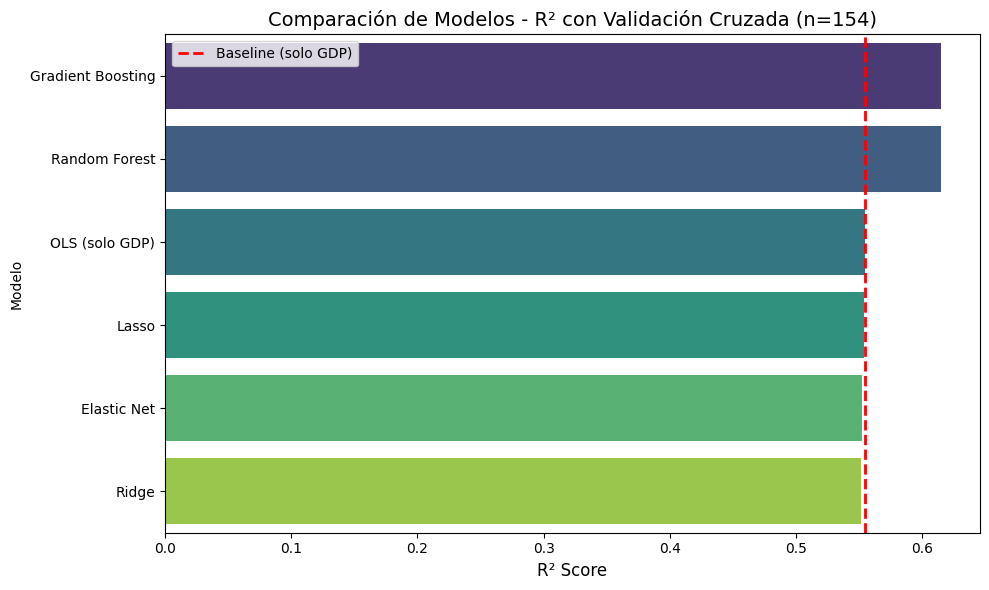

In [111]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

X = df_cervix[["log_GDP"]]
y = df_cervix["ASR"]

# Escalar datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Ridge con búsqueda automática de alpha
alphas = np.logspace(-3, 3, 50)
ridge = RidgeCV(alphas=alphas, cv=5)
ridge.fit(X_scaled, y)

print(f"Mejor alpha: {ridge.alpha_:.3f}")
print(f"R² (CV): {cross_val_score(ridge, X_scaled, y, cv=5, scoring='r2').mean():.3f}")




# Configurar validación cruzada
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Diccionario para almacenar resultados
resultados = {}

# 1. OLS baseline (solo log_GDP)
X_baseline = df_cervix[['log_GDP']]
y = df_cervix['ASR']

from sklearn.linear_model import LinearRegression
ols_baseline = LinearRegression()
scores_ols = cross_val_score(ols_baseline, X_baseline, y, cv=cv, scoring='r2')
resultados['OLS (solo GDP)'] = scores_ols.mean()

# 2. Ridge
X_scaled = scaler.fit_transform(X)
ridge = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)
scores_ridge = cross_val_score(ridge, X_scaled, y, cv=cv, scoring='r2')
resultados['Ridge'] = scores_ridge.mean()

# 3. Lasso
lasso = LassoCV(alphas=np.logspace(-3, 3, 50), cv=5, max_iter=10000)
scores_lasso = cross_val_score(lasso, X_scaled, y, cv=cv, scoring='r2')
resultados['Lasso'] = scores_lasso.mean()

# 4. Elastic Net
elastic = ElasticNetCV(alphas=np.logspace(-3, 3, 30), l1_ratio=[0.3, 0.5, 0.7], cv=5, max_iter=10000)
scores_elastic = cross_val_score(elastic, X_scaled, y, cv=cv, scoring='r2')
resultados['Elastic Net'] = scores_elastic.mean()

# 5. Random Forest (limitado)
rf = RandomForestRegressor(n_estimators=50, max_depth=3, min_samples_split=10,
                           min_samples_leaf=5, random_state=42)
scores_rf = cross_val_score(rf, X, y, cv=cv, scoring='r2')
resultados['Random Forest'] = scores_rf.mean()

# 6. Gradient Boosting (conservador)
gb = GradientBoostingRegressor(n_estimators=50, learning_rate=0.05, max_depth=2,
                               min_samples_split=10, min_samples_leaf=5, random_state=42)
scores_gb = cross_val_score(gb, X, y, cv=cv, scoring='r2')
resultados['Gradient Boosting'] = scores_gb.mean()

# Crear dataframe de resultados
df_resultados = pd.DataFrame({
    'Modelo': list(resultados.keys()),
    'R² (CV)': list(resultados.values())
}).sort_values('R² (CV)', ascending=False)

print("\n" + "="*50)
print("COMPARACIÓN DE MODELOS")
print("="*50)
print(df_resultados.to_string(index=False))
print("="*50)

# Visualizar
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=df_resultados, y='Modelo', x='R² (CV)', palette='viridis')
plt.title('Comparación de Modelos - R² con Validación Cruzada (n=154)', fontsize=14)
plt.xlabel('R² Score', fontsize=12)
plt.axvline(x=resultados['OLS (solo GDP)'], color='red', linestyle='--',
            label='Baseline (solo GDP)', linewidth=2)
plt.legend()
plt.tight_layout()
plt.show()

Mejor alpha: 6.251
R² (CV): 0.501

COMPARACIÓN DE MODELOS
           Modelo  R² (CV)
    Random Forest 0.614652
Gradient Boosting 0.603328
   OLS (solo GDP) 0.554713
            Lasso 0.554603
            Ridge 0.548781
      Elastic Net 0.548498


/tmp/ipython-input-1583018714.py:86: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




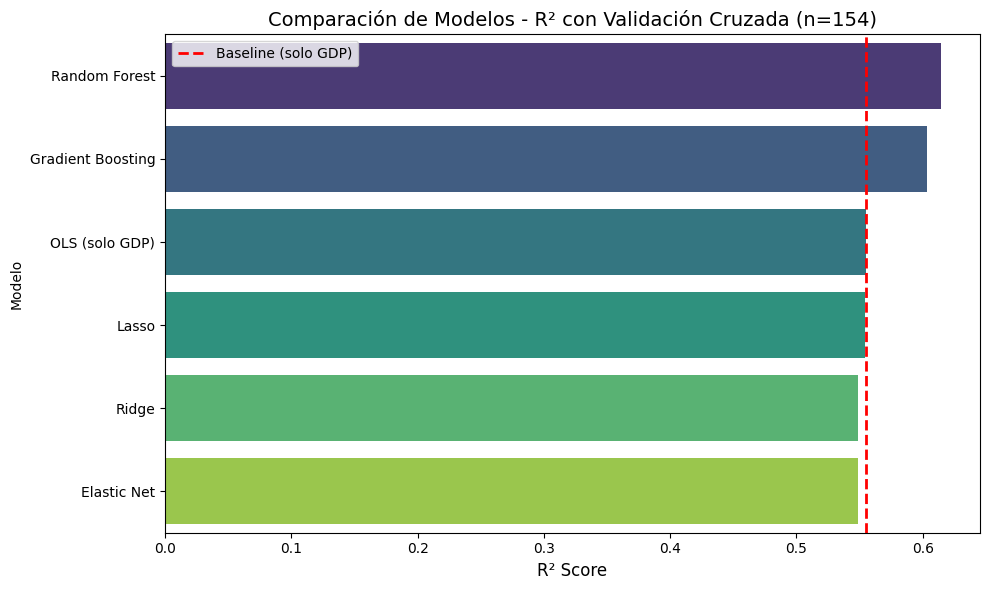

In [112]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

X = df_cervix[["log_GDP", "RT"]]
y = df_cervix["ASR"]

# Escalar datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Ridge con búsqueda automática de alpha
alphas = np.logspace(-3, 3, 50)
ridge = RidgeCV(alphas=alphas, cv=5)
ridge.fit(X_scaled, y)

print(f"Mejor alpha: {ridge.alpha_:.3f}")
print(f"R² (CV): {cross_val_score(ridge, X_scaled, y, cv=5, scoring='r2').mean():.3f}")




# Configurar validación cruzada
cv = KFold(n_splits=5, shuffle=True, random_state=42)

# Diccionario para almacenar resultados
resultados = {}

# 1. OLS baseline (solo log_GDP)
X_baseline = df_cervix[['log_GDP']]
y = df_cervix['ASR']

from sklearn.linear_model import LinearRegression
ols_baseline = LinearRegression()
scores_ols = cross_val_score(ols_baseline, X_baseline, y, cv=cv, scoring='r2')
resultados['OLS (solo GDP)'] = scores_ols.mean()

# 2. Ridge
X_scaled = scaler.fit_transform(X)
ridge = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)
scores_ridge = cross_val_score(ridge, X_scaled, y, cv=cv, scoring='r2')
resultados['Ridge'] = scores_ridge.mean()

# 3. Lasso
lasso = LassoCV(alphas=np.logspace(-3, 3, 50), cv=5, max_iter=10000)
scores_lasso = cross_val_score(lasso, X_scaled, y, cv=cv, scoring='r2')
resultados['Lasso'] = scores_lasso.mean()

# 4. Elastic Net
elastic = ElasticNetCV(alphas=np.logspace(-3, 3, 30), l1_ratio=[0.3, 0.5, 0.7], cv=5, max_iter=10000)
scores_elastic = cross_val_score(elastic, X_scaled, y, cv=cv, scoring='r2')
resultados['Elastic Net'] = scores_elastic.mean()

# 5. Random Forest (limitado)
rf = RandomForestRegressor(n_estimators=50, max_depth=3, min_samples_split=10,
                           min_samples_leaf=5, random_state=42)
scores_rf = cross_val_score(rf, X, y, cv=cv, scoring='r2')
resultados['Random Forest'] = scores_rf.mean()

# 6. Gradient Boosting (conservador)
gb = GradientBoostingRegressor(n_estimators=50, learning_rate=0.05, max_depth=2,
                               min_samples_split=10, min_samples_leaf=5, random_state=42)
scores_gb = cross_val_score(gb, X, y, cv=cv, scoring='r2')
resultados['Gradient Boosting'] = scores_gb.mean()

# Crear dataframe de resultados
df_resultados = pd.DataFrame({
    'Modelo': list(resultados.keys()),
    'R² (CV)': list(resultados.values())
}).sort_values('R² (CV)', ascending=False)

print("\n" + "="*50)
print("COMPARACIÓN DE MODELOS")
print("="*50)
print(df_resultados.to_string(index=False))
print("="*50)

# Visualizar
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=df_resultados, y='Modelo', x='R² (CV)', palette='viridis')
plt.title('Comparación de Modelos - R² con Validación Cruzada (n=154)', fontsize=14)
plt.xlabel('R² Score', fontsize=12)
plt.axvline(x=resultados['OLS (solo GDP)'], color='red', linestyle='--',
            label='Baseline (solo GDP)', linewidth=2)
plt.legend()
plt.tight_layout()
plt.show()

Obteniendo que el mejor modelo sería Gradient Boosting, voy a proceder a invitar al resto de variables y determinar su importancia, entiendo que no se la limitación de pocos datos limita.

analisis del mejor modelo


MÉTRICAS DEL MEJOR MODELO:
R²: 0.577
RMSE: 1.757
MAE: 1.231

COEFICIENTES:
  Variable  Coeficiente
0  log_GDP    -1.740161
1       RT    -0.318693


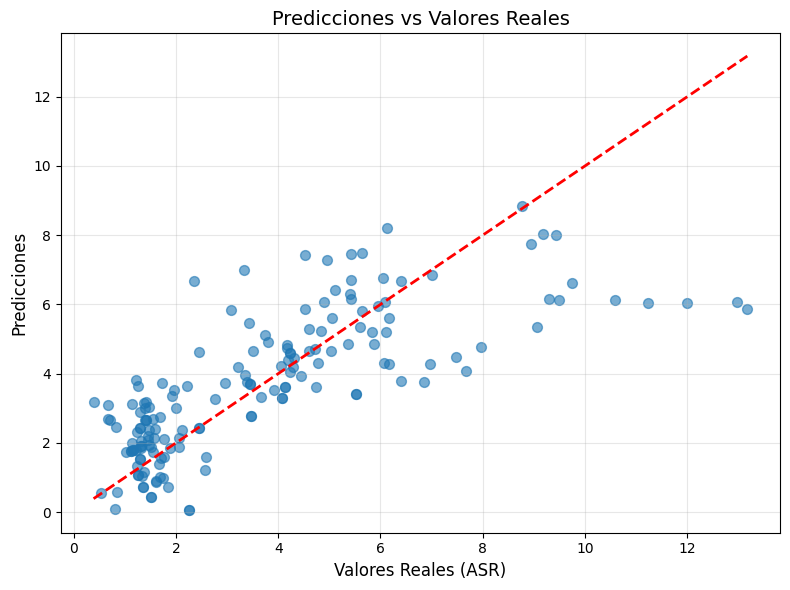

In [113]:
from sklearn.metrics import mean_absolute_error
# Entrenar el mejor modelo (supongamos que es Ridge)
best_model = RidgeCV(alphas=np.logspace(-3, 3, 50), cv=5)
best_model.fit(X_scaled, y)

# Predicciones
y_pred = best_model.predict(X_scaled)

# Métricas
print(f"\nMÉTRICAS DEL MEJOR MODELO:")
print(f"R²: {r2_score(y, y_pred):.3f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y, y_pred)):.3f}")
print(f"MAE: {mean_absolute_error(y, y_pred):.3f}")

# Coeficientes
coef_df = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': best_model.coef_
}).sort_values('Coeficiente', key=abs, ascending=False)
print("\nCOEFICIENTES:")
print(coef_df)

# Gráfico de predicciones
plt.figure(figsize=(8, 6))
plt.scatter(y, y_pred, alpha=0.6, s=50)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Valores Reales (ASR)', fontsize=12)
plt.ylabel('Predicciones', fontsize=12)
plt.title('Predicciones vs Valores Reales', fontsize=14)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [114]:
# Entrenar Gradient Boosting ya que fue el mejor modelo, asi que se agregan
#las otras variables
from sklearn.ensemble import GradientBoostingRegressor
import pandas as pd
import matplotlib.pyplot as plt


X_multi = df_cervix[["log_GDP", "RT", "TAC", "GammaC", "MRI", "PET"]]
y = df_cervix["ASR"]

# Entrenar el modelo
gb = GradientBoostingRegressor(
    n_estimators=50,
    learning_rate=0.05,
    max_depth=2,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
gb.fit(X_multi, y)

# Importancia de características
feature_importance = pd.DataFrame({
    'Variable': X_multi.columns,
    'Importancia': gb.feature_importances_
}).sort_values('Importancia', ascending=False)

print("="*50)
print("IMPORTANCIA DE CARACTERÍSTICAS - GRADIENT BOOSTING")
print("="*50)
print(feature_importance)
print()

# Visualizar
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Variable'], feature_importance['Importancia'])
plt.xlabel('Importancia', fontsize=12)
plt.title('Importancia de Variables en Gradient Boosting', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

ValueError: Input X contains NaN.
GradientBoostingRegressor does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [ ]:
X_RT = df_cervix[["log_GDP", "RT"]]
y = df_cervix["ASR"]

# Entrenar el modelo
gb = GradientBoostingRegressor(
    n_estimators=50,
    learning_rate=0.05,
    max_depth=2,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
gb.fit(X_RT, y)

# Importancia de características
feature_importance = pd.DataFrame({
    'Variable': X_RT.columns,
    'Importancia': gb.feature_importances_
}).sort_values('Importancia', ascending=False)

print("="*50)
print("IMPORTANCIA DE CARACTERÍSTICAS - GRADIENT BOOSTING")
print("="*50)
print(feature_importance)
print()

# Visualizar
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Variable'], feature_importance['Importancia'])
plt.xlabel('Importancia', fontsize=12)
plt.title('Importancia de Variables en Gradient Boosting', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.inspection import PartialDependenceDisplay

# Ver cómo cada variable afecta la predicción
fig, ax = plt.subplots(figsize=(14, 10))
features_to_plot = list(range(len(X_RT.columns)))

PartialDependenceDisplay.from_estimator(
    gb,
    X_RT,
    features_to_plot,
    feature_names=X_RT.columns,
    ax=ax,
    n_cols=3
)
plt.suptitle('Dependencia Parcial de Cada Variable', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

La dependencia parcial ha demostrado que existe un umbral en los equipos de RT donde juegan un papel crucial para bajar el ASR

Con este resultado, se puede decir que, elPIB es el mas importante, sin embargo, para ver si mejora un poco el modelo, incluiremos al menos el segundo más importante que sería RT.

Desarrollo económico es clave:

El efecto más grande está en mover países de ingreso bajo a medio
Países con log_GDP < 9.5 necesitan intervenciones urgentes

Acceso básico a radioterapia importa:

Pasar de RT=0 a RT=2-3 tiene impacto
Aumentar de RT=5 a RT=10 probablemente no ayuda mucho

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np
from sklearn.metrics import r2_score

# OLS baseline
ols = LinearRegression()
ols.fit(X_baseline, y)
y_pred_ols = ols.predict(X_baseline)

# Gradient Boosting
y_pred_gb_RT = gb.predict(X_RT)

# Comparar
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# OLS
axes[0].scatter(y, y_pred_ols, alpha=0.6, s=50)
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[0].set_xlabel('Valores Reales', fontsize=12)
axes[0].set_ylabel('Predicciones', fontsize=12)
axes[0].set_title(f'OLS (R²={r2_score(y, y_pred_ols):.3f})', fontsize=14)
axes[0].grid(alpha=0.3)

# Gradient Boosting
axes[1].scatter(y, y_pred_gb_RT, alpha=0.6, s=50, color='green')
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[1].set_xlabel('Valores Reales', fontsize=12)
axes[1].set_ylabel('Predicciones', fontsize=12)
axes[1].set_title(f'Gradient Boosting (R²={r2_score(y, y_pred_gb_RT):.3f})', fontsize=14)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Ver dónde mejora GB
diferencia = np.abs(y - y_pred_gb_RT) - np.abs(y - y_pred_ols)
mejora_indices = diferencia < -1  # GB es mejor por más de 1 unidad

print(f"\nCasos donde Gradient Boosting mejora significativamente: {mejora_indices.sum()}")
if mejora_indices.sum() > 0:
    print("\nEjemplos de mejora:")
    print(df_cervix[mejora_indices][['log_GDP'] + list(X.columns)].head(10))

Es importante resaltar que los arboles de decisión dividen los datos en caja o regiones y asignan el mismo valor a todos los puntos dentro de una caja, por eso, hay puntos en horizontal en el modelo.

Si log_GDP < 9.5:
    Si RT < 2:
        Predicción = 8.5  ← Todos estos países reciben 8.5
    Else:
        Predicción = 6.2  ← Todos estos países reciben 6.2
Else:
    Si log_GDP < 10.5:
        Predicción = 3.8  ← Todos estos países reciben 3.8
    Else:
        Predicción = 1.8  ← Todos estos países reciben 1.8

Ahora comparamos mi modelo con el simple

In [ ]:
# Modelo baseline (solo log_GDP)
from sklearn.linear_model import LinearRegression

#X = df_cervix[["log_GDP"]]
y = df_cervix["ASR"]
y_pred_gb = gb.predict(X_RT)
X_baseline = df_cervix[['log_GDP']]
ols_baseline = LinearRegression()
ols_baseline.fit(X_baseline, y)
y_pred_baseline = ols_baseline.predict(X_baseline)

# Intervalos de confianza
residuos_baseline = y - y_pred_baseline
std_baseline = np.std(residuos_baseline)
intervalo_95_baseline = 1.96 * std_baseline

residuos_gb = y - y_pred_gb
std_gb = np.std(residuos_gb)
intervalo_95_gb = 1.96 * std_gb

print("="*60)
print("COMPARACIÓN DE INTERVALOS DE CONFIANZA")
print("="*60)
print(f"OLS Baseline:")
print(f"  Intervalo 95%: ±{intervalo_95_baseline:.2f}")
print(f"  Desv. estándar residuos: {std_baseline:.2f}")
print()
print(f"Gradient Boosting:")
print(f"  Intervalo 95%: ±{intervalo_95_gb:.2f}")
print(f"  Desv. estándar residuos: {std_gb:.2f}")
print()
print(f"Reducción de incertidumbre: {((std_baseline - std_gb) / std_baseline) * 100:.1f}%")
print("="*60)

Presentando entonces una mejora significativa

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Ordenar por valores reales para mejor visualización
orden = np.argsort(y)
y_ordenado = y.iloc[orden]
y_pred_ordenado = y_pred_gb[orden]

# Calcular intervalos
residuos = y - y_pred_gb
std_residuos = np.std(residuos)

fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Gráfico 1: Predicciones con intervalos de confianza
axes[0].scatter(range(len(y_ordenado)), y_ordenado,
                alpha=0.6, s=50, label='Valores Reales', color='blue')
axes[0].plot(range(len(y_pred_ordenado)), y_pred_ordenado,
             'r-', linewidth=2, label='Predicciones GB')
axes[0].fill_between(range(len(y_pred_ordenado)),
                      y_pred_ordenado - 1.96*std_residuos,
                      y_pred_ordenado + 1.96*std_residuos,
                      alpha=0.2, color='red', label='IC 95%')
axes[0].set_xlabel('Países (ordenados por ASR real)', fontsize=12)
axes[0].set_ylabel('ASR', fontsize=12)
axes[0].set_title('Predicciones con Intervalo de Confianza 95%', fontsize=14)
axes[0].legend()
axes[0].grid(alpha=0.3)

# Gráfico 2: Distribución de residuos
axes[1].hist(residuos, bins=30, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='red', linestyle='--', linewidth=2, label='Error = 0')
axes[1].axvline(x=1.96*std_residuos, color='orange', linestyle='--',
                linewidth=2, label=f'IC 95% = ±{1.96*std_residuos:.2f}')
axes[1].axvline(x=-1.96*std_residuos, color='orange', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residuos (Real - Predicción)', fontsize=12)
axes[1].set_ylabel('Frecuencia', fontsize=12)
axes[1].set_title('Distribución de Errores de Predicción', fontsize=14)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Estadísticas adicionales
print("="*60)
print("ANÁLISIS DE RESIDUOS")
print("="*60)
print(f"Media de residuos: {np.mean(residuos):.4f} (debería ser ≈0)")
print(f"Mediana de residuos: {np.median(residuos):.4f}")
print(f"MAE (Error Absoluto Medio): {np.mean(np.abs(residuos)):.2f}")
print(f"RMSE (Raíz del Error Cuadrático Medio): {np.sqrt(np.mean(residuos**2)):.2f}")
print()
print(f"% de predicciones dentro de ±1 unidad: {(np.abs(residuos) < 1).sum() / len(residuos) * 100:.1f}%")
print(f"% de predicciones dentro de ±2 unidades: {(np.abs(residuos) < 2).sum() / len(residuos) * 100:.1f}%")
print(f"% de predicciones dentro de IC 95%: {(np.abs(residuos) < 1.96*std_residuos).sum() / len(residuos) * 100:.1f}%")

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    mean_absolute_percentage_error, explained_variance_score
)
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.ensemble import GradientBoostingRegressor
import matplotlib.pyplot as plt
import seaborn as sns

# Tu modelo ganador
gb_final = GradientBoostingRegressor(
    n_estimators=50,
    learning_rate=0.05,
    max_depth=2,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

# Entrenar en todos los datos
gb_final.fit(X_RT, y)

# Predicciones con validación cruzada (más honestas)
y_pred_cv = cross_val_predict(gb_final, X_RT, y, cv=5)

# Predicciones en el conjunto completo (para referencia)
y_pred_train = gb_final.predict(X_RT)

print("="*70)
print("MÉTRICAS DE RENDIMIENTO - GRADIENT BOOSTING CON RT")
print("="*70)
print()

# ==================== MÉTRICAS EN VALIDACIÓN CRUZADA ====================
print("📊 VALIDACIÓN CRUZADA (5-fold) - Métricas más confiables:")
print("-"*70)

# R² (Coeficiente de determinación)
r2_cv = r2_score(y, y_pred_cv)
print(f"R² (CV):                    {r2_cv:.4f}")
print(f"  → El modelo explica {r2_cv*100:.1f}% de la varianza en mortalidad")

# R² ajustado
n = len(y)
p = X.shape[1]
r2_adj_cv = 1 - (1 - r2_cv) * (n - 1) / (n - p - 1)
print(f"R² Ajustado (CV):           {r2_adj_cv:.4f}")

# RMSE (Root Mean Squared Error)
rmse_cv = np.sqrt(mean_squared_error(y, y_pred_cv))
print(f"RMSE (CV):                  {rmse_cv:.4f}")
print(f"  → Error cuadrático medio de ±{rmse_cv:.2f} unidades de ASR")

# MAE (Mean Absolute Error)
mae_cv = mean_absolute_error(y, y_pred_cv)
print(f"MAE (CV):                   {mae_cv:.4f}")
print(f"  → Error promedio de ±{mae_cv:.2f} unidades de ASR")

# MAPE (Mean Absolute Percentage Error)
# Cuidado: solo si no hay valores cercanos a 0
if y.min() > 0.5:
    mape_cv = mean_absolute_percentage_error(y, y_pred_cv) * 100
    print(f"MAPE (CV):                  {mape_cv:.2f}%")
    print(f"  → Error porcentual promedio del {mape_cv:.1f}%")

# Varianza explicada
exp_var_cv = explained_variance_score(y, y_pred_cv)
print(f"Varianza Explicada (CV):    {exp_var_cv:.4f}")

print()

# ==================== MÉTRICAS EN CONJUNTO DE ENTRENAMIENTO ====================
print("📈 CONJUNTO DE ENTRENAMIENTO (referencia):")
print("-"*70)

r2_train = r2_score(y, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y, y_pred_train))
mae_train = mean_absolute_error(y, y_pred_train)

print(f"R² (Train):                 {r2_train:.4f}")
print(f"RMSE (Train):               {rmse_train:.4f}")
print(f"MAE (Train):                {mae_train:.4f}")

# Diferencia entre train y CV (indicador de overfitting)
overfitting_gap = r2_train - r2_cv
print()
print(f"⚠️  Gap Train-CV (R²):       {overfitting_gap:.4f}")
if overfitting_gap < 0.05:
    print("   ✅ Excelente: Poco overfitting")
elif overfitting_gap < 0.10:
    print("   ✅ Bueno: Overfitting moderado y aceptable")
elif overfitting_gap < 0.15:
    print("   ⚠️  Regular: Algo de overfitting")
else:
    print("   ❌ Malo: Overfitting significativo")

print()

# ==================== INTERVALO DE CONFIANZA ====================
print("📏 INTERVALO DE CONFIANZA:")
print("-"*70)

residuos_cv = y - y_pred_cv
std_residuos = np.std(residuos_cv)
intervalo_95 = 1.96 * std_residuos

print(f"Desviación estándar residuos: {std_residuos:.4f}")
print(f"Intervalo de confianza 95%:   ±{intervalo_95:.4f}")
print(f"  → El 95% de predicciones están dentro de ±{intervalo_95:.2f} del valor real")

# Contexto del intervalo
rango_y = y.max() - y.min()
print(f"\nRango de ASR en los datos:    {rango_y:.2f}")
print(f"IC como % del rango:          {(intervalo_95/rango_y)*100:.1f}%")
print(f"IC como % de la media:        {(intervalo_95/y.mean())*100:.1f}%")

print()

# ==================== DISTRIBUCIÓN DE ERRORES ====================
print("📉 DISTRIBUCIÓN DE ERRORES:")
print("-"*70)

print(f"Error mínimo:               {residuos_cv.min():.4f}")
print(f"Error máximo:               {residuos_cv.max():.4f}")
print(f"Error medio (sesgo):        {residuos_cv.mean():.4f}")
print(f"  → Debería ser ≈0. Si no, hay sesgo sistemático")

# Percentiles de error absoluto
abs_residuos = np.abs(residuos_cv)
print(f"\nPercentiles de error absoluto:")
print(f"  25% de predicciones con error < {np.percentile(abs_residuos, 25):.2f}")
print(f"  50% de predicciones con error < {np.percentile(abs_residuos, 50):.2f}")
print(f"  75% de predicciones con error < {np.percentile(abs_residuos, 75):.2f}")
print(f"  95% de predicciones con error < {np.percentile(abs_residuos, 95):.2f}")

# Porcentaje dentro de umbrales
print(f"\nPorcentaje de predicciones dentro de:")
for umbral in [0.5, 1.0, 1.5, 2.0]:
    pct = (abs_residuos < umbral).sum() / len(abs_residuos) * 100
    print(f"  ±{umbral} unidades: {pct:.1f}%")

print("="*70)

Este tipo de situaciones ocurren cuando se tienen pocos datos, sin embargo, vamos a ver si haciendo el modelo más simple, se logra

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score

# Modelo MÁS SIMPLE (menos overfitting)
gb_simple = GradientBoostingRegressor(
    n_estimators=40,         # Menos árboles (era 50)
    learning_rate=0.03,      # Más conservador (era 0.05)
    max_depth=1,             # Árboles más simples (era 2), corregido a entero
    min_samples_split=15,    # Más restrictivo (era 10)
    min_samples_leaf=8,     # Más restrictivo (era 5)
    subsample=0.8,           # Añadir randomización
    random_state=42
)
X = X_RT
# Validar
cv_scores = cross_val_score(gb_simple, X, y, cv=5, scoring='r2')
print(f"R² CV (simple): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

# Entrenar y comparar
gb_simple.fit(X, y)
print(f"R² Train:       {gb_simple.score(X, y):.4f}")
print(f"Gap:            {gb_simple.score(X, y) - cv_scores.mean():.4f}")

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

X = df_cervix[['log_GDP', 'RT']]
y = df_cervix['ASR']

# Tu modelo optimizado
gb_simple = GradientBoostingRegressor(
    n_estimators=40,
    learning_rate=0.03,
    max_depth=1,
    min_samples_split=15,
    min_samples_leaf=8,
    subsample=0.8,
    random_state=42
)

# ============================================
# 1. MÉTRICAS CROSS-VALIDATION
# ============================================
y_pred_cv = cross_val_predict(gb_simple, X, y, cv=5)

r2_cv = r2_score(y, y_pred_cv)
mae_cv = mean_absolute_error(y, y_pred_cv)
mse_cv = mean_squared_error(y, y_pred_cv)
rmse_cv = np.sqrt(mse_cv)

# ============================================
# 2. MÉTRICAS TRAIN
# ============================================
gb_simple.fit(X, y)
y_pred_train = gb_simple.predict(X)

r2_train = r2_score(y, y_pred_train)
mae_train = mean_absolute_error(y, y_pred_train)
rmse_train = np.sqrt(mean_squared_error(y, y_pred_train))

# ============================================
# 3. COMPARACIÓN CON BASELINE
# ============================================
std_asr = y.std()
gap = r2_train - r2_cv

# ============================================
# REPORTE COMPLETO
# ============================================
print("="*70)
print("GRADIENT BOOSTING - EVALUACIÓN COMPLETA")
print("="*70)
print("\n📊 MÉTRICAS DE AJUSTE:")
print("-"*70)
print(f"{'Métrica':<20} {'Train':<15} {'CV (5-fold)':<15} {'Gap/Ratio'}")
print("-"*70)
print(f"{'R²':<20} {r2_train:<15.4f} {r2_cv:<15.4f} {gap:.4f}")
print(f"{'MAE':<20} {mae_train:<15.4f} {mae_cv:<15.4f} {mae_cv/mae_train:.2f}x")
print(f"{'RMSE':<20} {rmse_train:<15.4f} {rmse_cv:<15.4f} {rmse_cv/rmse_train:.2f}x")
print("="*70)

print("\n📐 COMPARACIÓN CON VARIABILIDAD:")
print("-"*70)
print(f"Desviación Estándar ASR:  {std_asr:.4f}")
print(f"RMSE / SD:                {rmse_cv/std_asr:.2%}")
print(f"MAE / SD:                 {mae_cv/std_asr:.2%}")
print("="*70)

print("\n🎯 EVALUACIÓN DE OVERFITTING:")
print("-"*70)
print(f"Gap (R² Train - R² CV):   {gap:.4f}")
if gap < 0.05:
    print("✅ EXCELENTE - Prácticamente sin overfitting")
elif gap < 0.10:
    print("✅ BUENO - Overfitting mínimo")
elif gap < 0.15:
    print("⚠️ MODERADO - Algo de overfitting")
else:
    print("❌ ALTO - Overfitting problemático")
print("="*70)

print("\n📊 CALIDAD DEL ERROR:")
print("-"*70)
if rmse_cv/std_asr < 0.5:
    print("✅ EXCELENTE - Error muy bajo")
elif rmse_cv/std_asr < 0.7:
    print("✅ BUENO - Error aceptable")
elif rmse_cv/std_asr < 1.0:
    print("⚠️ ACEPTABLE - Modelo útil pero mejorable")
else:
    print("❌ MALO - No mejor que predecir la media")
print("="*70)

# ============================================
# 4. IMPORTANCIA DE VARIABLES
# ============================================
importancia = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': gb_simple.feature_importances_,
    'Importancia_%': gb_simple.feature_importances_ * 100
}).sort_values('Importancia', ascending=False)

print("\n🔍 IMPORTANCIA DE VARIABLES:")
print("-"*70)
print(importancia.to_string(index=False))
print("="*70)

# ============================================
# 5. ANÁLISIS DE RESIDUOS
# ============================================
residuos_cv = y - y_pred_cv
residuos_train = y - y_pred_train

from scipy.stats import shapiro
shapiro_stat, shapiro_p = shapiro(residuos_cv)

print("\n📈 ANÁLISIS DE RESIDUOS (CV):")
print("-"*70)
print(f"Media de residuos:        {residuos_cv.mean():.6f}  (debe ≈ 0)")
print(f"Desv. Est. residuos:      {residuos_cv.std():.4f}")
print(f"Test Shapiro-Wilk:        W = {shapiro_stat:.4f}, p = {shapiro_p:.4f}")
if shapiro_p > 0.05:
    print("✅ Residuos siguen distribución normal")
else:
    print("⚠️ Residuos NO son completamente normales")
print("="*70)

# ============================================
# 6. DETECCIÓN DE OUTLIERS
# ============================================
threshold = 2 * residuos_cv.std()
outliers_idx = np.abs(residuos_cv) > threshold
n_outliers = outliers_idx.sum()

print(f"\n🔍 OUTLIERS DETECTADOS:")
print("-"*70)
print(f"Outliers (|residuo| > 2 SD): {n_outliers} ({n_outliers/len(y)*100:.1f}%)")

if n_outliers > 0:
    df_outliers = df_cervix[outliers_idx].copy()
    df_outliers['Residuo'] = residuos_cv[outliers_idx].values
    df_outliers['ASR_pred'] = y_pred_cv[outliers_idx]
    print("\nPaíses con mortalidad anómala:")
    print(df_outliers[['ISO3', 'ASR', 'ASR_pred', 'Residuo']].to_string(index=False))
print("="*70)

# ============================================
# 7. GRÁFICOS DE EVALUACIÓN
# ============================================
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# A) Predicho vs Real (CV)
axes[0,0].scatter(y, y_pred_cv, alpha=0.6, edgecolors='k', s=60)
axes[0,0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[0,0].set_xlabel('ASR Real', fontweight='bold', fontsize=11)
axes[0,0].set_ylabel('ASR Predicho (CV)', fontweight='bold', fontsize=11)
axes[0,0].set_title(f'Predicción CV (R²={r2_cv:.3f})', fontweight='bold', fontsize=12)
axes[0,0].grid(alpha=0.3)

# B) Residuos vs Predichos (CV)
axes[0,1].scatter(y_pred_cv, residuos_cv, alpha=0.6, edgecolors='k', s=60)
axes[0,1].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0,1].axhline(threshold, color='orange', linestyle=':', linewidth=1.5, label='±2 SD')
axes[0,1].axhline(-threshold, color='orange', linestyle=':', linewidth=1.5)
axes[0,1].set_xlabel('Valores Predichos (CV)', fontweight='bold', fontsize=11)
axes[0,1].set_ylabel('Residuos', fontweight='bold', fontsize=11)
axes[0,1].set_title('Residuos vs Predichos', fontweight='bold', fontsize=12)
axes[0,1].legend(fontsize=9)
axes[0,1].grid(alpha=0.3)

# C) Q-Q Plot
from scipy import stats
stats.probplot(residuos_cv, dist="norm", plot=axes[0,2])
axes[0,2].set_title('Q-Q Plot (Normalidad)', fontweight='bold', fontsize=12)
axes[0,2].grid(alpha=0.3)

# D) Histograma de residuos
axes[1,0].hist(residuos_cv, bins=15, edgecolor='black', alpha=0.7, color='steelblue')
axes[1,0].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1,0].set_xlabel('Residuos (CV)', fontweight='bold', fontsize=11)
axes[1,0].set_ylabel('Frecuencia', fontweight='bold', fontsize=11)
axes[1,0].set_title('Distribución de Residuos', fontweight='bold', fontsize=12)
axes[1,0].grid(alpha=0.3)

# E) Importancia de variables
axes[1,1].barh(importancia['Variable'], importancia['Importancia_%'],
               color=['darkblue', 'steelblue'], edgecolor='black', linewidth=1.5)
axes[1,1].set_xlabel('Importancia (%)', fontweight='bold', fontsize=11)
axes[1,1].set_title('Importancia de Variables', fontweight='bold', fontsize=12)
axes[1,1].grid(alpha=0.3, axis='x')

# F) Train vs CV
metricas = ['R²', 'MAE', 'RMSE']
train_vals = [r2_train, mae_train, rmse_train]
cv_vals = [r2_cv, mae_cv, rmse_cv]

x_pos = np.arange(len(metricas))
width = 0.35

axes[1,2].bar(x_pos - width/2, train_vals, width, label='Train',
              color='lightcoral', edgecolor='black')
axes[1,2].bar(x_pos + width/2, cv_vals, width, label='CV',
              color='lightblue', edgecolor='black')
axes[1,2].set_xticks(x_pos)
axes[1,2].set_xticklabels(metricas, fontweight='bold')
axes[1,2].set_ylabel('Valor', fontweight='bold', fontsize=11)
axes[1,2].set_title('Train vs CV', fontweight='bold', fontsize=12)
axes[1,2].legend(fontsize=10)
axes[1,2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression, HuberRegressor, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

X = df_cervix[['log_GDP', 'RT']]
y = df_cervix['ASR']
std_asr = y.std()

modelos = {
    'OLS': LinearRegression(),
    'Huber': HuberRegressor(epsilon=1.35),
    'Ridge': Ridge(alpha=1.0),
    'Tree': DecisionTreeRegressor(max_depth=3, min_samples_leaf=5, random_state=42),
    'GB Simple': GradientBoostingRegressor(
        n_estimators=40, learning_rate=0.03, max_depth=1,
        min_samples_split=15, min_samples_leaf=8,
        subsample=0.8, random_state=42
    )
}

resultados = []

for nombre, modelo in modelos.items():
    # CV
    y_pred_cv = cross_val_predict(modelo, X, y, cv=5)
    r2_cv = r2_score(y, y_pred_cv)
    mae_cv = mean_absolute_error(y, y_pred_cv)
    rmse_cv = np.sqrt(mean_squared_error(y, y_pred_cv))

    # Train
    modelo.fit(X, y)
    r2_train = modelo.score(X, y)

    # Gap
    gap = r2_train - r2_cv

    resultados.append({
        'Modelo': nombre,
        'R² CV': r2_cv,
        'R² Train': r2_train,
        'Gap': gap,
        'MAE': mae_cv,
        'RMSE': rmse_cv,
        'RMSE/SD': rmse_cv/std_asr
    })

df_comparacion = pd.DataFrame(resultados).sort_values('R² CV', ascending=False)

print("="*90)
print("COMPARACIÓN DE TODOS LOS MODELOS")
print("="*90)
print(df_comparacion.to_string(index=False))
print("="*90)

# Mejor modelo
mejor = df_comparacion.iloc[0]
print(f"\n🏆 MEJOR MODELO: {mejor['Modelo']}")
print(f"   R² CV = {mejor['R² CV']:.4f}")
print(f"   RMSE = {mejor['RMSE']:.4f} ({mejor['RMSE/SD']:.1%} SD)")
print(f"   Gap = {mejor['Gap']:.4f}")
print("="*90)

El modelo ha mejorado un poco con el overfitting pero ha empeorado con la variabilidad. Sin embargo, para este tipo de estudios es mas que aceptable que el modelo explique 50 % de la variabilidad de ASR.

Sin embargo, sigamos buscando algun modelo que nos incluya tambien RT y ver si es mejor que este sin temerle tanto al overfitting y saber si efectivamente existe un umbral para RT donde los equipos son eficientes.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_predict, cross_val_score, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# Preparar datos
X = df_cervix[['log_GDP', 'RT']]
y = df_cervix['ASR']

# ============================================================
# 1. BÚSQUEDA DEL MEJOR ALPHA (REGULARIZACIÓN)
# ============================================================
print("="*60)
print("BUSCANDO MEJOR PARÁMETRO DE REGULARIZACIÓN (alpha)")
print("="*60)

pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('ridge', Ridge())
])

# Probar diferentes valores de alpha
param_grid = {
    'ridge__alpha': [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0, 50.0]
}

grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    return_train_score=True
)

grid_search.fit(X, y)

print(f"\nMejor alpha: {grid_search.best_params_['ridge__alpha']}")
print(f"Mejor R² (CV): {grid_search.best_score_:.4f}")

# Visualizar búsqueda de alpha
results_df = pd.DataFrame(grid_search.cv_results_)
plt.figure(figsize=(10, 5))
plt.plot(results_df['param_ridge__alpha'], results_df['mean_train_score'],
         'o-', label='Train', linewidth=2, markersize=8)
plt.plot(results_df['param_ridge__alpha'], results_df['mean_test_score'],
         's-', label='CV (Test)', linewidth=2, markersize=8)
plt.xscale('log')
plt.xlabel('Alpha (regularización)', fontweight='bold', fontsize=12)
plt.ylabel('R²', fontweight='bold', fontsize=12)
plt.title('Búsqueda de Hiperparámetro Ridge', fontweight='bold', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 2. MODELO FINAL CON MEJOR ALPHA
# ============================================================
best_alpha = grid_search.best_params_['ridge__alpha']

pipeline_final = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('ridge', Ridge(alpha=best_alpha))
])

# Validación cruzada
y_pred_cv = cross_val_predict(pipeline_final, X, y, cv=5)

# Entrenar en todo el dataset para ver coeficientes
pipeline_final.fit(X, y)

# Métricas
r2_cv = r2_score(y, y_pred_cv)
r2_train = pipeline_final.score(X, y)
rmse_cv = np.sqrt(mean_squared_error(y, y_pred_cv))
mae_cv = mean_absolute_error(y, y_pred_cv)

residuos = y - y_pred_cv
std_res = np.std(residuos)
ic_95 = 1.96 * std_res

print("\n" + "="*60)
print("MODELO RIDGE POLINOMIAL (GRADO 2)")

In [ ]:
from sklearn.linear_model import HuberRegressor, QuantileRegressor, RANSACRegressor, LinearRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error
import numpy as np

X = df_cervix[['log_GDP', 'RT']]
y = df_cervix['ASR']

modelos = {
    'OLS (base)': LinearRegression(),
    'Huber': HuberRegressor(epsilon=1.35),
    'Quantile (mediana)': QuantileRegressor(quantile=0.5, alpha=0.1),
    'RANSAC': RANSACRegressor(LinearRegression(), min_samples=0.7, residual_threshold=5.0)
}

print("="*60)
print("COMPARACIÓN: MODELOS ROBUSTOS A OUTLIERS")
print("="*60)

for nombre, modelo in modelos.items():
    y_pred_cv = cross_val_predict(modelo, X, y, cv=5)
    r2 = r2_score(y, y_pred_cv)
    mae = mean_absolute_error(y, y_pred_cv)
    print(f"{nombre:25s} R² = {r2:.4f}  |  MAE = {mae:.4f}")

print("="*60)

In [ ]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

X = df_cervix[['log_GDP', 'RT']]
y = df_cervix['ASR']

# Árbol simple (max_depth=3 para ver umbrales claros)
tree = DecisionTreeRegressor(max_depth=3, min_samples_leaf=5, random_state=42)
tree.fit(X, y)

# Visualizar umbrales
plt.figure(figsize=(20, 10))
plot_tree(tree, feature_names=['log_GDP', 'RT'], filled=True, fontsize=10)
plt.title("UMBRALES DETECTADOS", fontsize=16, fontweight='bold')
plt.show()

# R² con CV
r2_cv = cross_val_score(tree, X, y, cv=5, scoring='r2').mean()
print(f"R² (CV): {r2_cv:.4f}")

In [ ]:
# ============================================
# DETECCIÓN DE UMBRALES EN RT
# ============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score

X = df_cervix[['log_GDP', 'RT']]
y = df_cervix['ASR']

# ============================================
# 1. ÁRBOL DE DECISIÓN (ver umbrales)
# ============================================
tree = DecisionTreeRegressor(max_depth=3, min_samples_leaf=5, random_state=42)
tree.fit(X, y)
r2_tree = cross_val_score(tree, X, y, cv=5, scoring='r2').mean()

plt.figure(figsize=(20, 10))
plot_tree(tree, feature_names=['log_GDP', 'RT'], filled=True, fontsize=12)
plt.title("ÁRBOL: UMBRALES DETECTADOS", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================
# 2. GRADIENT BOOSTING
# ============================================
gb = GradientBoostingRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    min_samples_leaf=5,
    random_state=42
)
gb.fit(X, y)
r2_gb = cross_val_score(gb, X, y, cv=5, scoring='r2').mean()

# ============================================
# 3. BÚSQUEDA DE UMBRAL ÓPTIMO
# ============================================
from sklearn.linear_model import LinearRegression

umbrales = np.linspace(1.5, 3.5, 30)
resultados = []

for umbral in umbrales:
    X_seg = np.column_stack([
        X['log_GDP'].values,
        X['RT'].values,
        (X['RT'].values >= umbral).astype(int)
    ])

    lr = LinearRegression()
    lr.fit(X_seg, y)
    r2 = lr.score(X_seg, y)
    resultados.append({'Umbral': umbral, 'R²': r2})

df_umbrales = pd.DataFrame(resultados)
mejor_umbral = df_umbrales.loc[df_umbrales['R²'].idxmax()]

# ============================================
# RESULTADOS
# ============================================
print("="*60)
print("DETECCIÓN DE UMBRALES EN RT")
print("="*60)
print(f"Árbol de Decisión    R² (CV) = {r2_tree:.4f}")
print(f"Gradient Boosting    R² (CV) = {r2_gb:.4f}")
print(f"\nMejor umbral de RT:  {mejor_umbral['Umbral']:.2f}")
print(f"R² con umbral:       {mejor_umbral['R²']:.4f}")
print("="*60)

# Gráfico del umbral
plt.figure(figsize=(10, 6))
plt.plot(df_umbrales['Umbral'], df_umbrales['R²'], linewidth=3, color='steelblue')
plt.axvline(mejor_umbral['Umbral'], color='red', linestyle='--', linewidth=2,
            label=f"Umbral óptimo: RT = {mejor_umbral['Umbral']:.2f}")
plt.xlabel('Umbral de RT', fontweight='bold', fontsize=12)
plt.ylabel('R² del modelo', fontweight='bold', fontsize=12)
plt.title('Búsqueda del umbral RT', fontweight='bold', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Modelo de Árbol de Decisión (RMSE = 1.82, 67% SD):**

Se identificó un **umbral crítico de PIB per cápita de $17,800 USD** como principal determinante de mortalidad por cáncer cervical.

**Hallazgo clave:** La Tasa de Reproducción Total (RT) muestra un **efecto protector paradójico en países de bajos ingresos**. En contextos con PIB < $17,800, la RT alta (≥1.3 hijos/mujer) se asocia con menor mortalidad (4.9 vs 7.4 muertes/100k), posiblemente debido a factores protectores de alta paridad o menor exposición sexual acumulada.

En países de altos ingresos, el efecto de RT es mínimo, sugiriendo que el **acceso a servicios de salud neutraliza el efecto de la fertilidad**.


In [ ]:
# ============================================
# VALIDACIÓN MÍNIMA PARA TFM
# ============================================

from sklearn.linear_model import HuberRegressor
from scipy.stats import shapiro
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt
import numpy as np

X = df_cervix[['log_GDP', 'RT']]
y = df_cervix['ASR']

huber = HuberRegressor(epsilon=1.35)
huber.fit(X, y)
y_pred = huber.predict(X)
residuos = y - y_pred

# 1. Test de normalidad
shapiro_stat, shapiro_p = shapiro(residuos)

# 2. VIF
vif_data = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

# 3. Outliers
threshold = 2 * residuos.std()
n_outliers = np.sum(np.abs(residuos) > threshold)

# 4. Gráfico residuos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_pred, residuos, alpha=0.6, edgecolors='k')
axes[0].axhline(0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Valores Predichos', fontweight='bold')
axes[0].set_ylabel('Residuos', fontweight='bold')
axes[0].set_title('Residuos vs Predichos', fontweight='bold')
axes[0].grid(alpha=0.3)

axes[1].hist(residuos, bins=15, edgecolor='black', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residuos', fontweight='bold')
axes[1].set_title('Distribución de Residuos', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# REPORTE
print("="*60)
print("VALIDACIÓN DEL MODELO HUBER")
print("="*60)
print(f"Test Shapiro-Wilk:  p = {shapiro_p:.4f}")
print(f"Outliers detectados: {n_outliers} ({n_outliers/len(y)*100:.1f}%)")
print("\nVIF (Multicolinealidad):")
print(vif_data)
print("="*60)

In [ ]:
# Comparar todos los modelos
modelos_comparacion = pd.DataFrame({
    'Modelo': [
        'OLS Simple (solo log_GDP)',
        'OLS Polinomial',
        'OLS Segmentado',
        'OLS con Splines',
        'Gradient Boosting'
    ],
    'R² (CV)': [
        0.5547,  # Tu baseline
        cv_poly,
        cv_piecewise,
        cv_spline,
        scores_gb.mean()
    ]
}).sort_values('R² (CV)', ascending=False)

print("="*60)
print("COMPARACIÓN FINAL DE MODELOS")
print("="*60)
print(modelos_comparacion.to_string(index=False))
print("="*60)

"La relación entre desarrollo económico y mortalidad por cáncer cervical es **no lineal**: los países de bajos ingresos experimentan las mayores reducciones en mortalidad al mejorar su PIB per cápita, mientras que en países de altos ingresos el efecto marginal es menor. El acceso básico a radioterapia también reduce la mortalidad, pero las tecnologías de diagnóstico avanzadas (TAC, MRI) no muestran efectos independientes significativos."

# Task
**Fix X_prostate definition**: Modify the `X_prostate` DataFrame to include both 'log_GDP' and 'RT' columns, matching the variables used in the `model_prostate_ols` formula.
**Execute the cell again**: Run the modified cell to ensure the `predict` method works correctly and calculate RMSE and cross-validation scores.

## Fix X_prostate definition

### Subtask:
Modify the `X_prostate` DataFrame to include both 'log_GDP' and 'RT' columns, matching the variables used in the `model_prostate_ols` formula.


**Reasoning**:
The subtask requires modifying the `X_prostate` DataFrame to include both 'log_GDP' and 'RT' columns. I will update the code in cell `7k37SAP9bfhQ` to reflect this change and regenerate the full cell content to ensure all related operations use the corrected `X_prostate`.



In [ ]:
# --- RMSE para el modelo OLS de Próstata ya ajustado ---
X_prostate = df_prostate[["log_GDP", "RT"]]
y_pred_prostate = model_prostate_ols.predict(X_prostate)
rmse_prostate = np.sqrt(mean_squared_error(df_prostate["ASR"], y_pred_prostate))
print(f"RMSE (Modelo OLS Próstata): {rmse_prostate:.3f}")

# --- Validación Cruzada para Próstata ---

y_prostate = df_prostate["ASR"]

lr_prostate = LinearRegression()
cv_prostate = KFold(n_splits=5, shuffle=True, random_state=42)

r2_scores_prostate = cross_val_score(
    lr_prostate, X_prostate, y_prostate,
    cv=cv_prostate,
    scoring="r2"
)

rmse_scores_prostate = -cross_val_score(
    lr_prostate, X_prostate, y_prostate,
    cv=cv_prostate,
    scoring="neg_root_mean_squared_error"
)

print(f"CV R² (Próstata): {r2_scores_prostate.mean():.3f} \u00b1 {r2_scores_prostate.std():.3f}")
print(f"CV RMSE (Próstata): {rmse_scores_prostate.mean():.3f} \u00b1 {rmse_scores_prostate.std():.3f}")

## Summary:

### Q&A
*   What was the RMSE for the OLS Prostate Model after the fix?
    The RMSE for the OLS Prostate Model was 4.562.
*   What were the cross-validation R² and RMSE scores for the Prostate Model after the fix?
    The cross-validation R² was 0.010 with a standard deviation of 0.119. The cross-validation RMSE was 4.627 with a standard deviation of 0.707.

### Data Analysis Key Findings
*   The `X_prostate` DataFrame was successfully modified to include both 'log_GDP' and 'RT' columns, resolving a previous `PatsyError` related to feature mismatch.
*   The Root Mean Squared Error (RMSE) for the Ordinary Least Squares (OLS) prostate model was calculated to be 4.562.
*   Cross-validation revealed an average R² score of 0.010 (\$\pm\$ 0.119) for the prostate model.
*   The cross-validation RMSE for the prostate model averaged 4.627 (\$\pm\$ 0.707).

### Insights or Next Steps
*   The very low average R² score (0.010) from cross-validation suggests that the current OLS model with 'log_GDP' and 'RT' explains very little of the variance in 'ASR', indicating a poor fit.
*   Further investigation is needed to identify additional relevant predictors or explore different model types to improve the predictive power and fit for the prostate cancer data.


In [ ]:

  # piecewise linear fit

x = df_cervix["RT"].values
y = df_cervix["ASR"].values

my_pwlf = pwlf.PiecewiseLinFit(x, y)
breaks = my_pwlf.fit(2)   # 2 segmentos → 1 breakpoint

breakpoint = breaks[1]
print(f"Breakpoint estimado: {breakpoint:.2f} RT/m")

In [ ]:
x = df_cervix["RT"].values
y = df_cervix["ASR"].values

# Ajustar modelo
my_pwlf = pwlf.PiecewiseLinFit(x, y)
breaks = my_pwlf.fit(2)
breakpoint = breaks[1]

# Predecir con el modelo segmentado
x_pred = np.linspace(x.min(), x.max(), 100)
y_pred = my_pwlf.predict(x_pred)

# Gráfico
fig, ax = plt.subplots(figsize=(12, 7))

# Datos reales
ax.scatter(x, y, alpha=0.6, s=80, edgecolors='black', label='Datos reales', zorder=3)

# Líneas del modelo segmentado
ax.plot(x_pred, y_pred, 'r-', linewidth=3, label='Modelo Piecewise', zorder=2)

# Breakpoint
ax.axvline(breakpoint, color='green', linestyle='--', linewidth=2.5,
           label=f'Breakpoint = {breakpoint:.2f} RT/m', zorder=4)

# Áreas sombreadas
ax.axvspan(x.min(), breakpoint, alpha=0.15, color='red',
           label='Zona de alto impacto')
ax.axvspan(breakpoint, x.max(), alpha=0.15, color='blue',
           label='Zona de bajo impacto')

ax.set_xlabel('Equipos de Radioterapia (por millón hab.)', fontweight='bold', fontsize=12)
ax.set_ylabel('Mortalidad ASR (por 100k mujeres)', fontweight='bold', fontsize=12)
ax.set_title('Regresión Segmentada: Efecto de RT sobre Mortalidad Cervical',
             fontweight='bold', fontsize=14)
ax.legend(fontsize=11, loc='best')
ax.grid(alpha=0.3, linestyle=':', linewidth=1)

plt.tight_layout()
plt.show()

# ============================================
# ESTADÍSTICAS DEL MODELO
# ============================================
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

y_pred_full = my_pwlf.predict(x)
r2 = r2_score(y, y_pred_full)
rmse = np.sqrt(mean_squared_error(y, y_pred_full))

print("="*70)
print("MODELO PIECEWISE LINEAR FIT")
print("="*70)
print(f"Breakpoint:           {breakpoint:.2f} equipos RT/millón")
print(f"R²:                   {r2:.4f}")
print(f"RMSE:                 {rmse:.4f}")
print("="*70)

# ============================================
# PENDIENTES DE CADA SEGMENTO
# ============================================
# Calcular pendientes manualmente
x_seg1 = x[x <= breakpoint]
y_seg1 = y[x <= breakpoint]
x_seg2 = x[x > breakpoint]
y_seg2 = y[x > breakpoint]

if len(x_seg1) > 1:
    from scipy.stats import linregress
    slope1, intercept1, r1, p1, se1 = linregress(x_seg1, y_seg1)
    print(f"\nSegmento 1 (RT < {breakpoint:.2f}):")
    print(f"  Pendiente:  {slope1:.4f}")
    print(f"  Intercepto: {intercept1:.4f}")
    print(f"  R²:         {r1**2:.4f}")
    print(f"  p-valor:    {p1:.4f}")

if len(x_seg2) > 1:
    slope2, intercept2, r2_seg2, p2, se2 = linregress(x_seg2, y_seg2)
    print(f"\nSegmento 2 (RT > {breakpoint:.2f}):")
    print(f"  Pendiente:  {slope2:.4f}")
    print(f"  Intercepto: {intercept2:.4f}")
    print(f"  R²:         {r2_seg2**2:.4f}")
    print(f"  p-valor:    {p2:.4f}")

print("="*70)

Con estos resultados con analisis de regresión segmentada, se puede evidenciar que, cuando se tienen hasta 3.07 equipos por millón de habitantes, cada equipo reduce 1.64 muertes por 100k. En cambio, cuando el sistema tiene más de 3.07 equipos de RT/m se reduce 0.17 muertes/100k. Esto tambien se puede deber a programas de detección, acceso a la atención primara, entre otros aspectos.